
DATASET: sp500_monthly
Raw data shape: (18380, 8)
After dropna, shape: (12080, 14)
X shape: (11072, 24, 6)
y shape: (11072, 1)
Train samples: 8857  |  Test samples: 2215

Model summary:


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 24, 6)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_layer (LSTM)                   │ (None, 64)                  │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_layer (Dense)                  │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Activation)                  │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.2260e-04 - val_loss: 1.2988e-05
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9858e-04 - val_loss: 1.1075e-05
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9636e-04 - val_loss: 1.0224e-05
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9495e-04 - val_loss: 1.0065e-05
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9487e-04 - val_loss: 9.9286e-06
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9427e-04 - val_loss: 1.1057e-05
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9282e-04 - val_loss: 1.1666e-05
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9159e-04 - val_loss: 1.1655e-05
Epoch 9/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.9078e-04 - val_loss: 1.1300e-05
Epoch 10/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9020e-04 - val_loss: 1.0816e-05
Epoch 11/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss

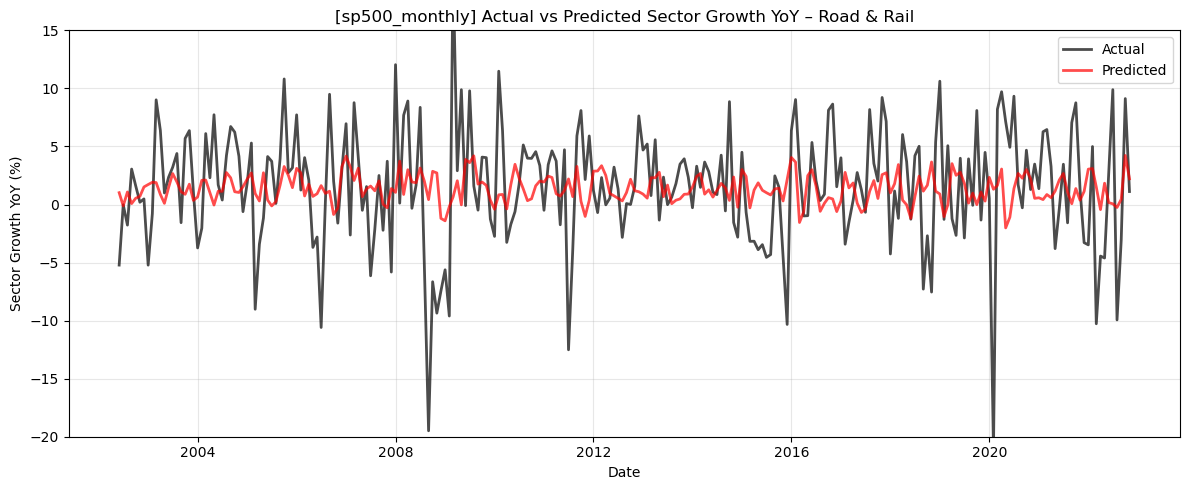

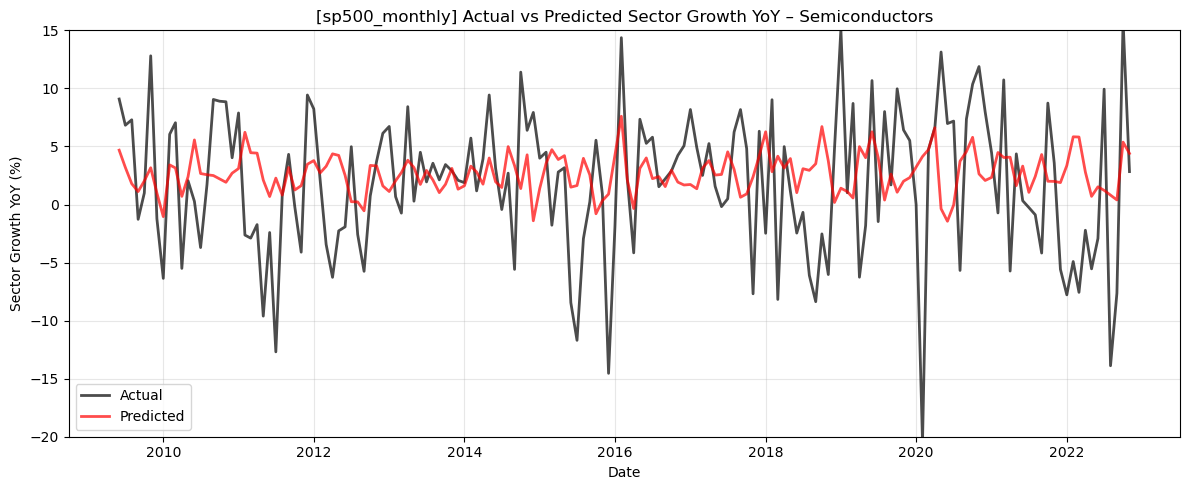

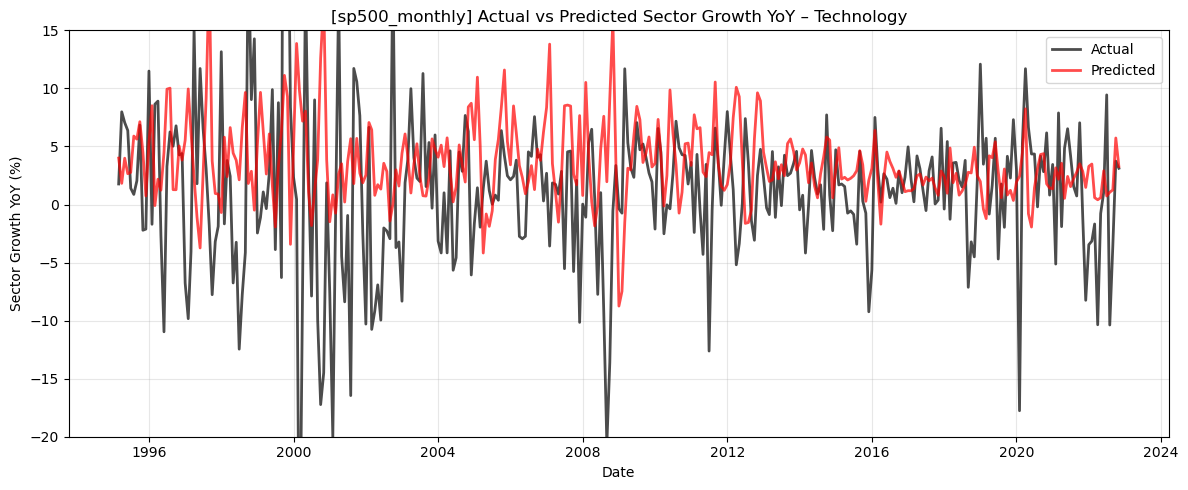

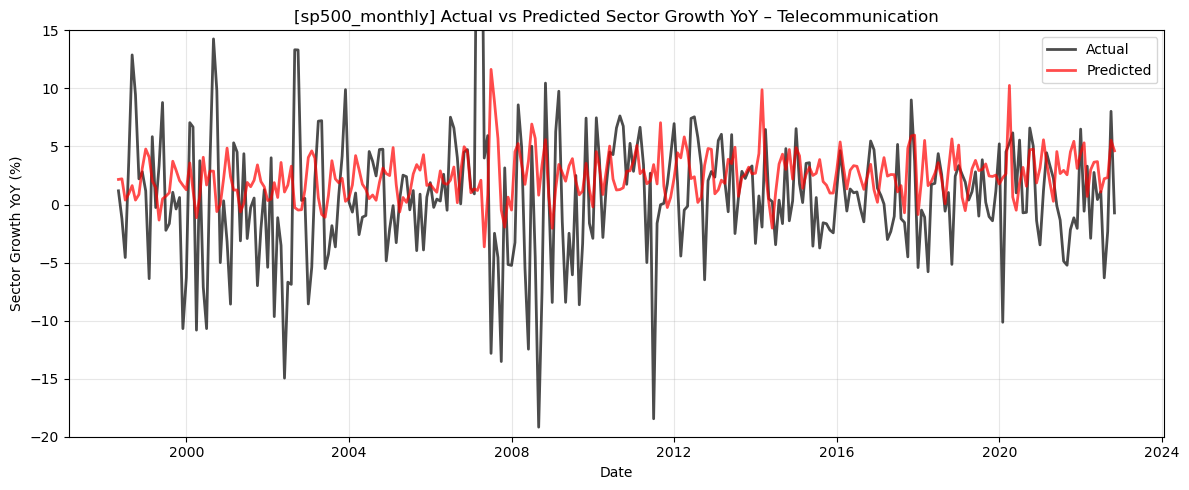

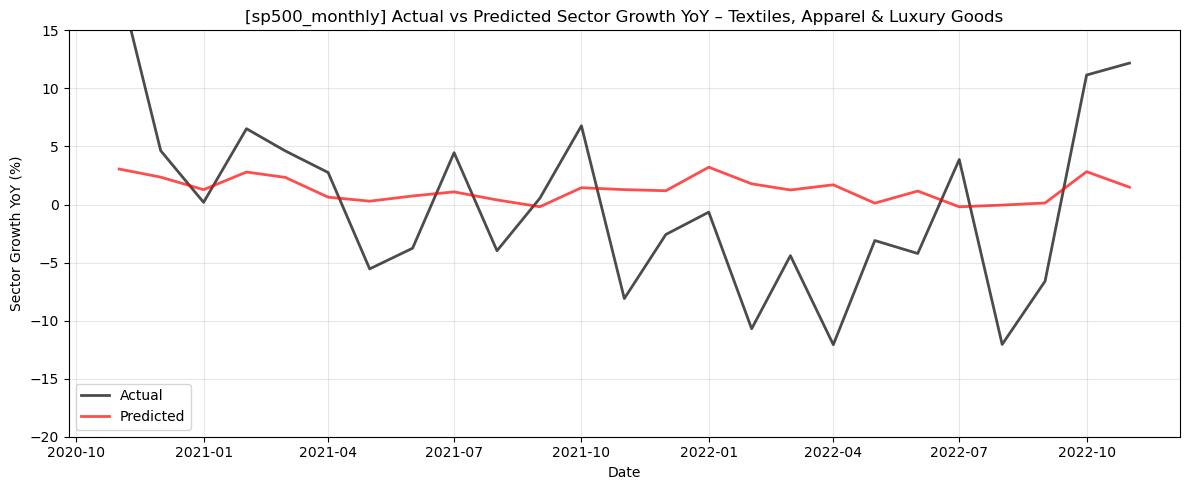

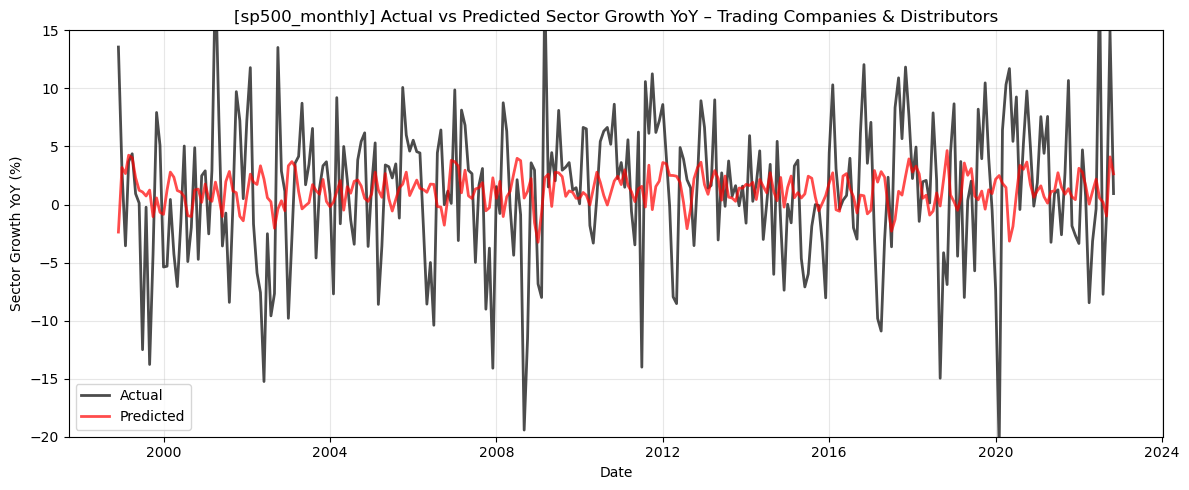

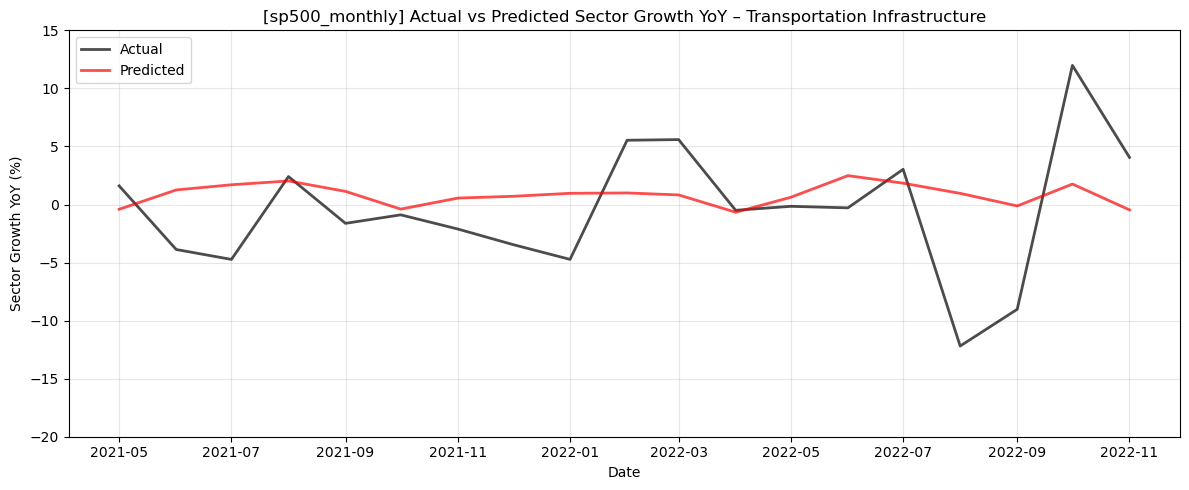

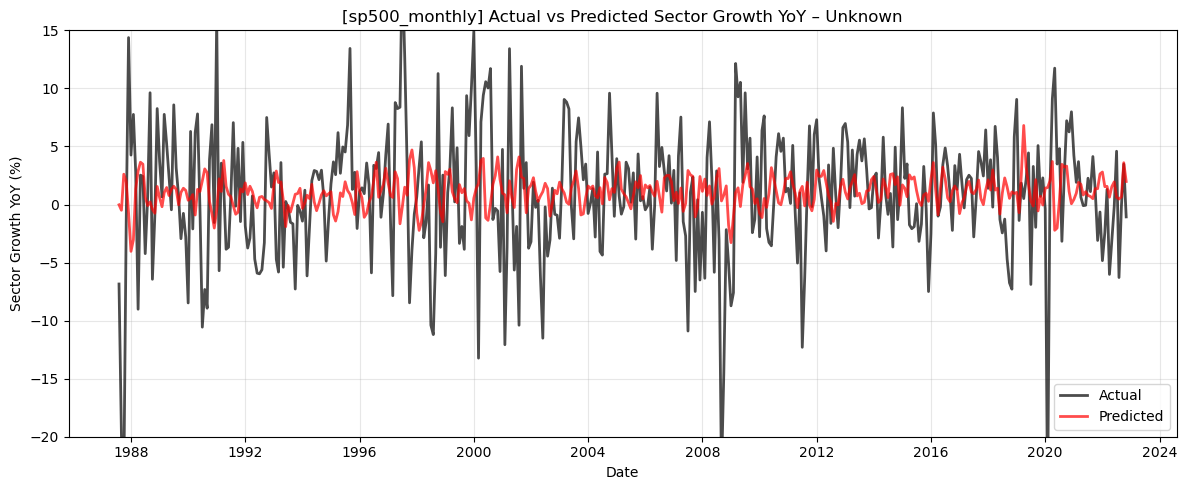

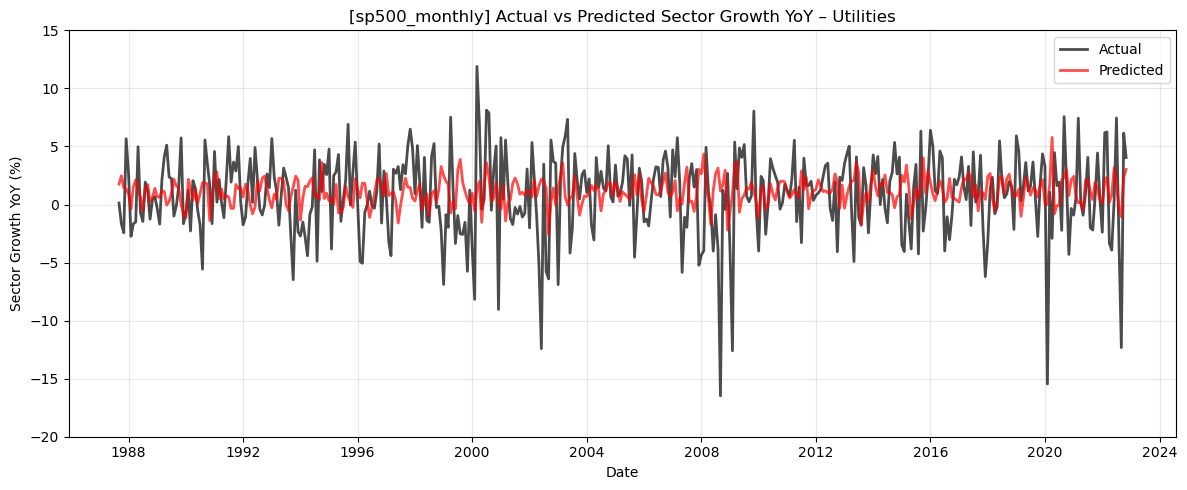


PER-SECTOR METRICS (sp500_monthly)

----------------------------------------------------------------------
Sector: Road & Rail
MAE  : 3.9424
RMSE : 5.1957
R²   : -0.0186
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
2002-06-01     -5.2171      1.0169     -6.2341
2002-07-01     -0.0178     -0.1176      0.0998
2002-08-01     -1.7747      1.0782     -2.8529
2002-09-01      3.0520      0.0793      2.9727
2002-10-01      1.6104      0.5370      1.0734

----------------------------------------------------------------------
Sector: Semiconductors
MAE  : 5.1058
RMSE : 6.4712
R²   : -0.0937
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
2009-06-01      9.0847      4.6791      4.4056
2009-07-01      6.8264   

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandas_ta as ta

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Activation
from tensorflow.keras.optimizers import Adam

# ============================================================
# 0. GLOBAL CONFIG
# ============================================================

BASE_DIR = r'C:/Users/Abel/Downloads/PAN4/Semester 1/Data Analytics and Data Mining (CSC1171)/group_project/new_datasets'
BACKCANDLES = 24       # history length

np.random.seed(10)
tf.random.set_seed(10)

pd.set_option('display.max_columns', None)

# ------------------------------------------------------------
# simple manual MinMax
# ------------------------------------------------------------
def minmax_fit(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        raise ValueError("minmax_fit received empty array.")
    min_vals = arr.min(axis=0)
    max_vals = arr.max(axis=0)
    denom = max_vals - min_vals
    denom[denom == 0.0] = 1.0
    return min_vals, max_vals

def minmax_transform(arr, min_vals, max_vals):
    arr = np.asarray(arr, dtype=float)
    denom = max_vals - min_vals
    denom[denom == 0.0] = 1.0
    return (arr - min_vals) / denom

def build_sequences_multi_sector(df, feat_cols_sc, target_col, backcandles, date_col="Date"):
    X_list, y_list = [], []
    meta_sector, meta_date = [], []

    for sector_name, grp in df.groupby('sector'):
        grp = grp.sort_values(date_col)
        feat_vals = grp[feat_cols_sc].values   # (T, n_features)
        tgt_vals  = grp[target_col].values     # (T,)
        dates     = grp[date_col].values

        if len(grp) <= backcandles:
            continue

        for i in range(backcandles, len(grp)):
            X_list.append(feat_vals[i-backcandles:i, :])
            y_list.append(tgt_vals[i])
            meta_sector.append(sector_name)
            meta_date.append(dates[i])

    X_arr = np.array(X_list)                  # (samples, backcandles, n_features)
    y_arr = np.array(y_list).reshape(-1, 1)   # (samples, 1)
    return X_arr, y_arr, np.array(meta_sector), np.array(meta_date)

# ---------- metric helpers ----------
def mse(a, b):
    return np.mean((a - b) ** 2)

def mae(a, b):
    return np.mean(np.abs(a - b))

def r2(a, b):
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

# ============================================================
# MAIN PIPELINE FOR ONE DATASET
# ============================================================

def run_lstm_for_dataset(csv_path, dataset_name):
    print("\n" + "="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)

    # 1. LOAD DATA
    if not os.path.exists(csv_path):
        print(f"CSV not found: {csv_path}  → skipping")
        return

    data = pd.read_csv(csv_path)
    print(f"Raw data shape: {data.shape}")

    # Normalise time column to 'Date'
    if 'YearMonth' in data.columns:
        data['Date'] = pd.to_datetime(data['YearMonth'])
    elif 'Year' in data.columns:
        data['Date'] = pd.to_datetime(data['Year'].astype(int).astype(str) + '-01-01')
    else:
        print("No 'YearMonth' or 'Year' column found → skipping dataset")
        return

    data = data.sort_values(['sector', 'Date']).reset_index(drop=True)

    # 2. ADD INDICATORS ON sector_growth_yoy (PER SECTOR)
    data['RSI'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.rsi(s, length=15))
    )

    data['EMAF'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=20))
    )

    data['EMAM'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=100))
    )

    data['EMAS'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=150))
    )

    # 3. TARGET = NEXT-PERIOD sector_growth_yoy PER SECTOR
    data['Target'] = (
        data.groupby('sector')['sector_growth_yoy']
            .shift(-1)
    )

    data = data.dropna().reset_index(drop=True)
    print(f"After dropna, shape: {data.shape}")

    if len(data) == 0:
        print("No rows left after dropna (indicators/Target) → skipping this dataset")
        return

    # 4. FEATURES & SCALING
    feature_cols = [
        'avg_return',
        'avg_adj_close',
        'avg_volume',
        'RSI',
        'EMAF',
        'EMAM',
    ]
    target_col = 'Target'

    # sanity-check columns exist
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        print(f"Missing feature columns {missing} in {dataset_name} → skipping")
        return

    feat = data[feature_cols].values
    tgt  = data[target_col].values.reshape(-1, 1)

    if feat.shape[0] == 0:
        print("No feature rows after selection → skipping dataset")
        return

    feat_min, feat_max = minmax_fit(feat)
    feat_scaled = minmax_transform(feat, feat_min, feat_max)

    scaled_feat_cols = [c + '_sc' for c in feature_cols]
    data[scaled_feat_cols] = feat_scaled

    # 5. BUILD SEQUENCES
    X, y, sectors_arr, dates_arr = build_sequences_multi_sector(
        data,
        scaled_feat_cols,
        target_col,
        BACKCANDLES,
        date_col="Date",
    )

    if len(X) == 0:
        print("Not enough data to build sequences → skipping dataset")
        return

    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    # 6. TRAIN–TEST SPLIT
    split_idx = int(len(X) * 0.8)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    sectors_test = sectors_arr[split_idx:]
    dates_test   = dates_arr[split_idx:]

    print(f"Train samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")

    n_features = X.shape[2]

    # SCALE TARGET (MinMax on training part only)
    y_min = y_train.min()
    y_max = y_train.max()
    y_range = y_max - y_min if (y_max - y_min) != 0 else 1.0

    y_train_sc = (y_train - y_min) / y_range
    y_test_sc  = (y_test  - y_min) / y_range

    # 7. BUILD AND TRAIN LSTM
    lstm_input = Input(shape=(BACKCANDLES, n_features), name='lstm_input')
    x = LSTM(64, name='first_layer')(lstm_input)
    x = Dense(1, name='dense_layer')(x)
    output = Activation('linear', name='output')(x)

    model = Model(inputs=lstm_input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

    print("\nModel summary:")
    model.summary()

    history = model.fit(
        X_train, y_train_sc,
        batch_size=32,
        epochs=30,
        shuffle=True,
        validation_split=0.1,
        verbose=1
    )

    # 8. PREDICT (IN REAL UNITS)
    y_pred_sc = model.predict(X_test)
    y_pred = y_pred_sc * y_range + y_min

    # 9. PLOT TEST vs PREDICTED – PER SECTOR
    unique_sectors = np.unique(sectors_test)

    for sector in unique_sectors:
        mask = (sectors_test == sector)

        sector_dates = dates_test[mask]
        sector_y_true = y_test[mask][:, 0]
        sector_y_pred = y_pred[mask][:, 0]

        sort_idx = np.argsort(sector_dates)
        sector_dates = sector_dates[sort_idx]
        sector_y_true = sector_y_true[sort_idx]
        sector_y_pred = sector_y_pred[sort_idx]

        plt.figure(figsize=(12, 5))
        plt.plot(
            sector_dates, sector_y_true,
            label='Actual', color='black', linewidth=2, alpha=0.7
        )
        plt.plot(
            sector_dates, sector_y_pred,
            label='Predicted', color='red', linewidth=2, alpha=0.7
        )
        plt.xlabel('Date')
        plt.ylabel('Sector Growth YoY (%)')
        plt.ylim(-20, 15)
        plt.title(f'[{dataset_name}] Actual vs Predicted Sector Growth YoY – {sector}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 10. PER-SECTOR METRICS
    sector_summary = []

    print("\n" + "="*70)
    print(f"PER-SECTOR METRICS ({dataset_name})")
    print("="*70)

    for sector in unique_sectors:
        mask = (sectors_test == sector)

        sector_dates = dates_test[mask]
        sector_y_true = y_test[mask][:, 0]
        sector_y_pred = y_pred[mask][:, 0]

        sort_idx = np.argsort(sector_dates)
        sector_dates = sector_dates[sort_idx]
        sector_y_true = sector_y_true[sort_idx]
        sector_y_pred = sector_y_pred[sort_idx]

        sector_mae = mae(sector_y_true, sector_y_pred)
        sector_rmse = np.sqrt(mse(sector_y_true, sector_y_pred))
        sector_r2 = r2(sector_y_true, sector_y_pred)

        sector_summary.append({
            "Sector": sector,
            "MAE": sector_mae,
            "RMSE": sector_rmse,
            "R2": sector_r2,
        })

        print("\n" + "-"*70)
        print(f"Sector: {sector}")
        print(f"MAE  : {sector_mae:.4f}")
        print(f"RMSE : {sector_rmse:.4f}")
        print(f"R²   : {sector_r2:.4f}")
        print("-"*70)
        print(f"{'Date':<12} {'Actual':>10} {'Predicted':>12} {'Error':>12}")
        print("-"*70)

        for i in range(min(5, len(sector_y_true))):
            err = sector_y_true[i] - sector_y_pred[i]
            print(
                f"{str(sector_dates[i])[:10]:<12}"
                f"{sector_y_true[i]:10.4f}"
                f"{sector_y_pred[i]:12.4f}"
                f"{err:12.4f}"
            )

    # compact summary
    print("\n" + "="*70)
    print(f"SUMMARY TABLE ({dataset_name})")
    print("="*70)
    for row in sector_summary:
        print(
            f"{row['Sector']:<30} "
            f"MAE={row['MAE']:.4f}  "
            f"RMSE={row['RMSE']:.4f}  "
            f"R²={row['R2']:.4f}"
        )

# ============================================================
# RUN FOR ALL DATASETS
# ============================================================

DATASETS = [
    "sp500_monthly",
]

for ds in DATASETS:
    csv_path = os.path.join(BASE_DIR, f"{ds}.csv")
    run_lstm_for_dataset(csv_path, ds)



DATASET: forbes2000_yearly
Raw data shape: (1553, 8)
After dropna on features+Target, shape: (1301, 14)
X shape: (1259, 1, 5)
y shape: (1259, 1)
Train samples: 1007  |  Test samples: 252

Model summary:


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 1, 5)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_layer (LSTM)                   │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_layer (Dense)                  │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Activation)                  │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 5.0904e-06
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 1.3859e-05
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 3.4553e-05
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 3.9111e-05
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 3.5318e-05
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 3.3168e-05
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.2529e-05
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 3.2215e-05
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.1922e-05
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.1649e-05
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.1404e-05
Epoch 12/30
29/29 ━━━━━━━━━━━

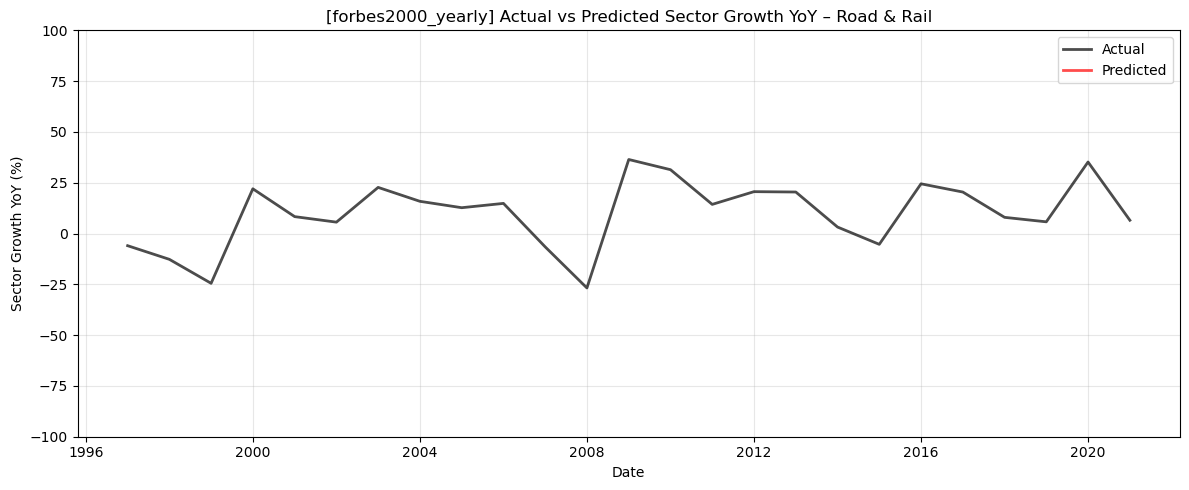

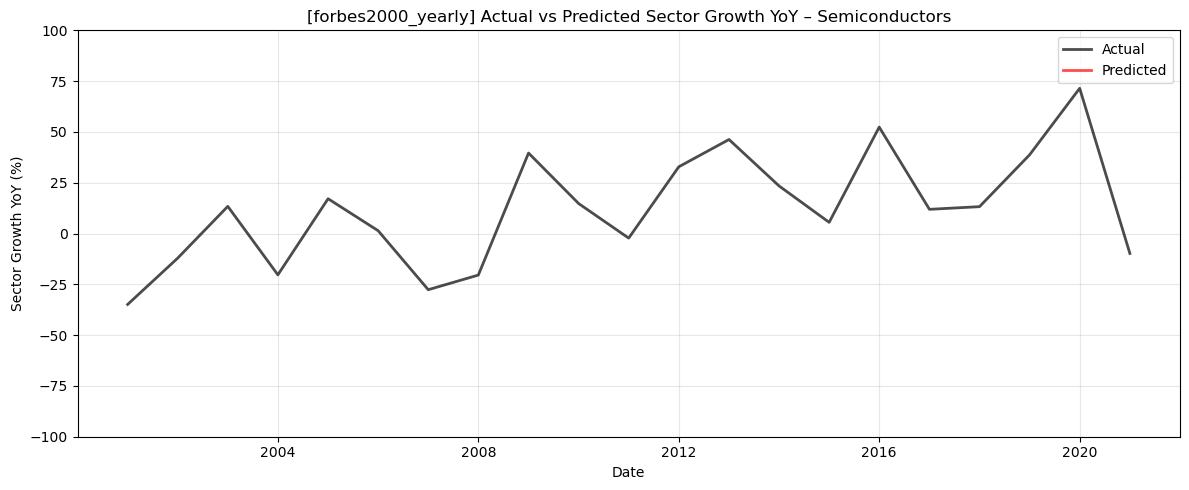

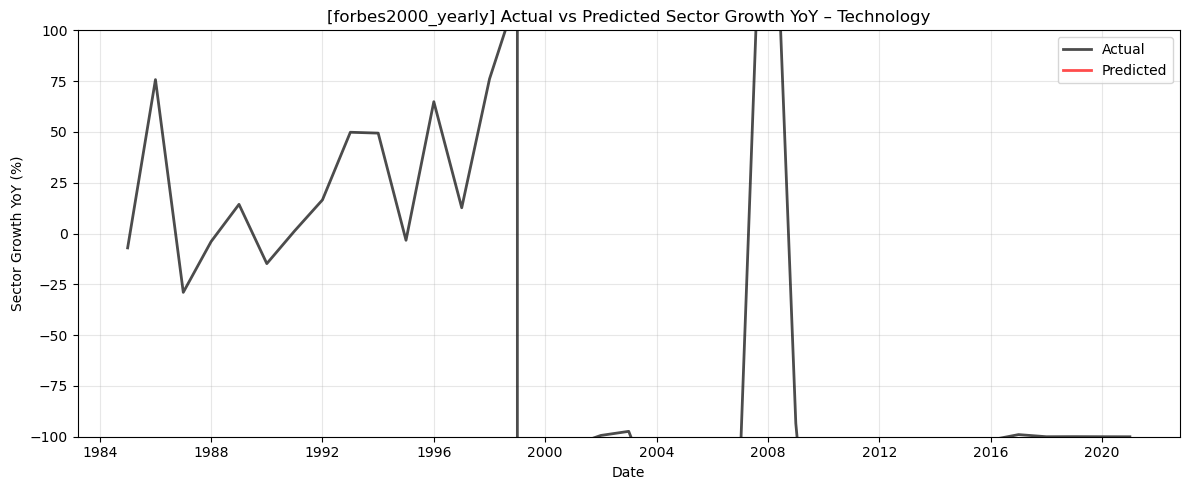

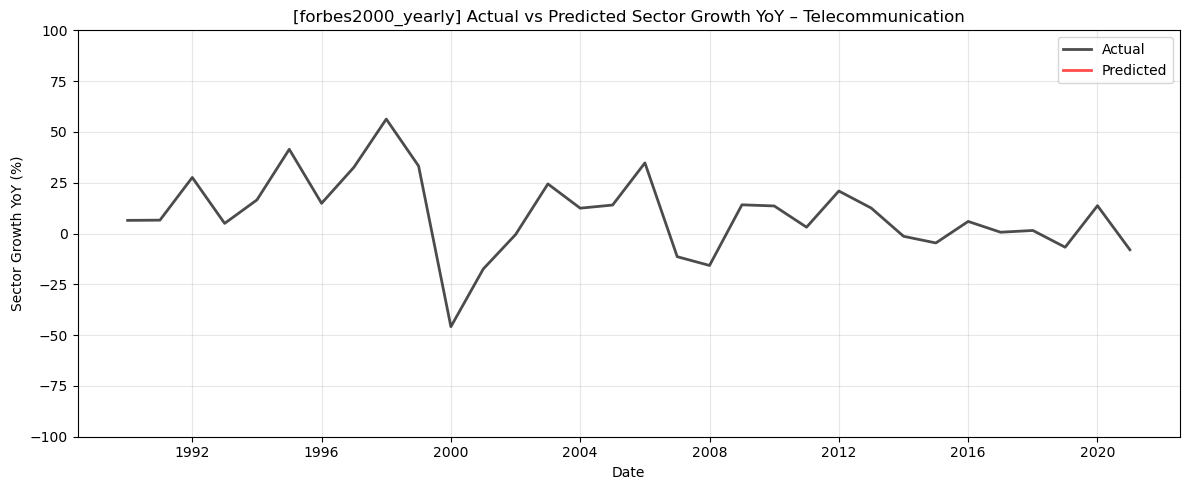

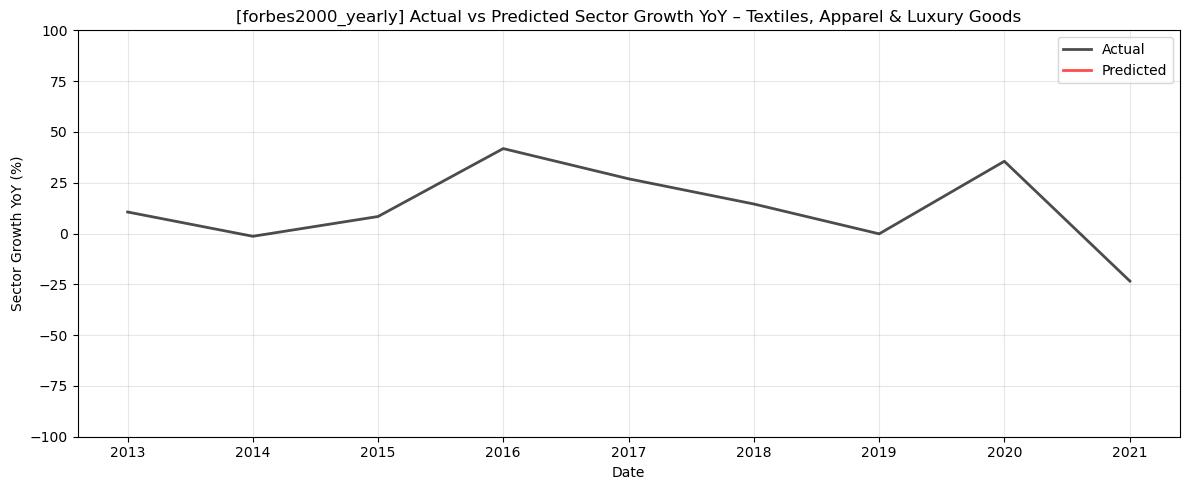

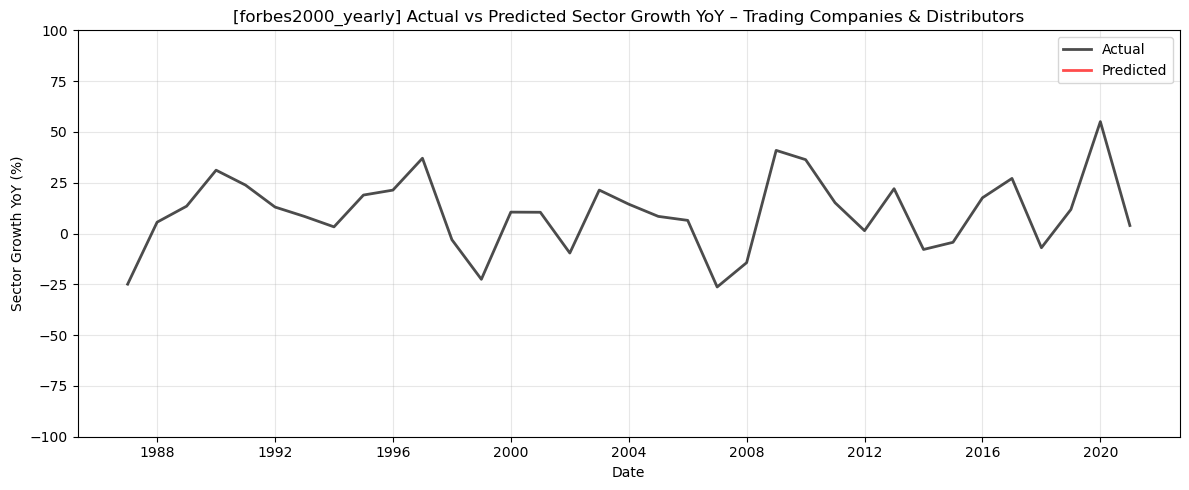

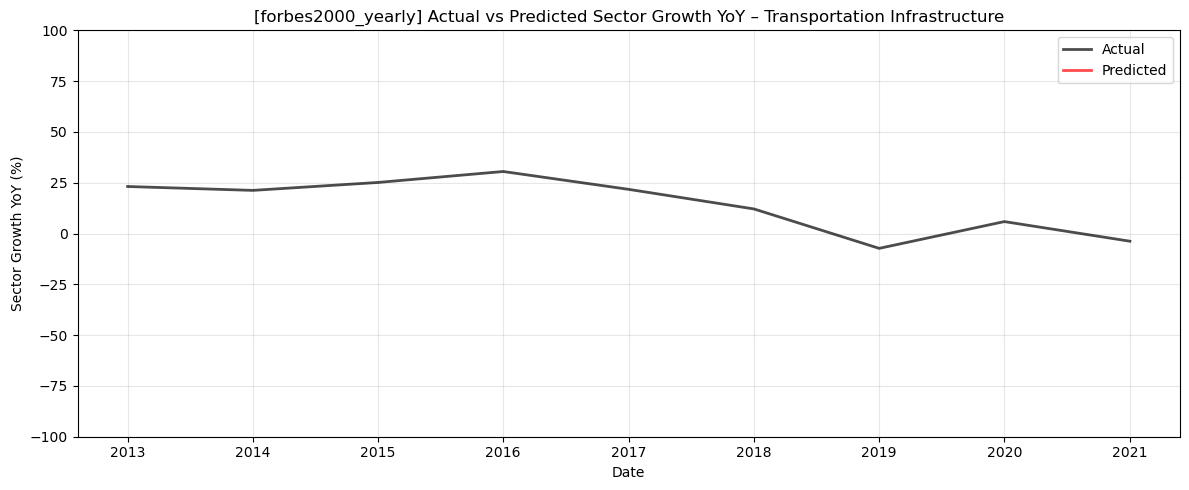

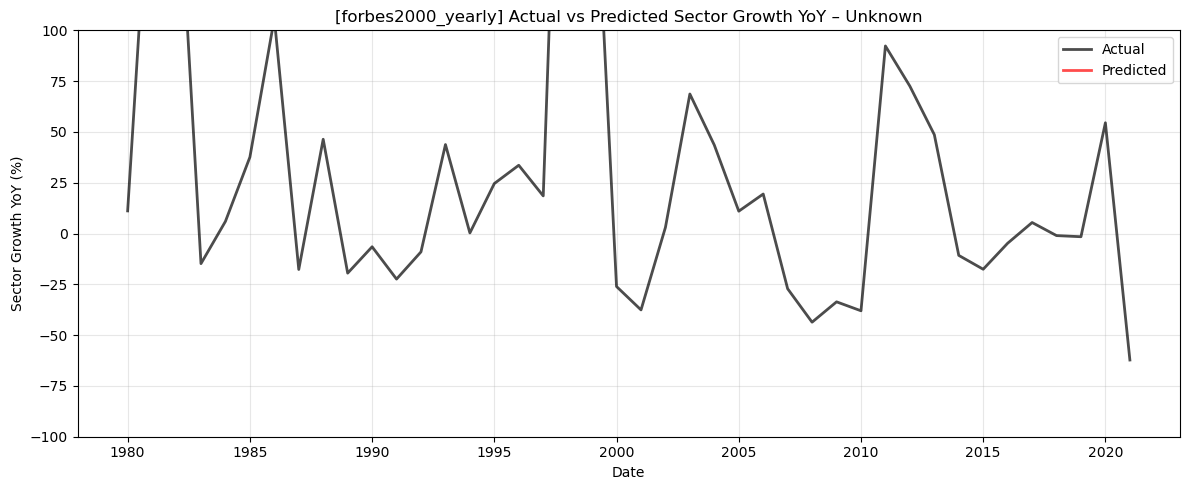

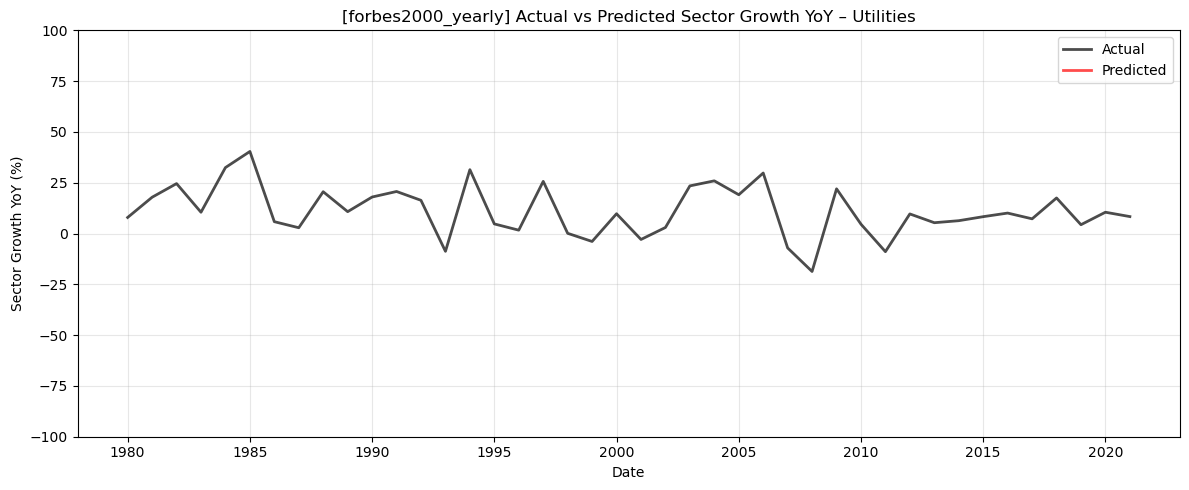


PER-SECTOR METRICS (forbes2000_yearly)

----------------------------------------------------------------------
Sector: Road & Rail
MAE  : 230834.1695
RMSE : 232529.7167
R²   : -203381106.6442
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
1997-01-01     -5.9886 243637.3438-243643.3323
1998-01-01    -12.7051 209640.2344-209652.9395
1999-01-01    -24.4977 203033.1406-203057.6384
2000-01-01     22.0094 188962.7812-188940.7718
2001-01-01      8.3178 168968.8594-168960.5416

----------------------------------------------------------------------
Sector: Semiconductors
MAE  : 239447.1117
RMSE : 240366.0181
R²   : -77262581.1524
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
2001-01-01    -34.9012 245635.765

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 1, 5)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_layer (LSTM)                   │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_layer (Dense)                  │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Activation)                  │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 2.5476e-05
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 3.3162e-05
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6411e-05
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6041e-05
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6120e-05
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6007e-05
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6046e-05
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 2.6101e-05
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011 - val_loss: 2.6197e-05
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6280e-05
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 2.6365e-05
Epoch 12/30
29/29 ━━━━━━━━━━━

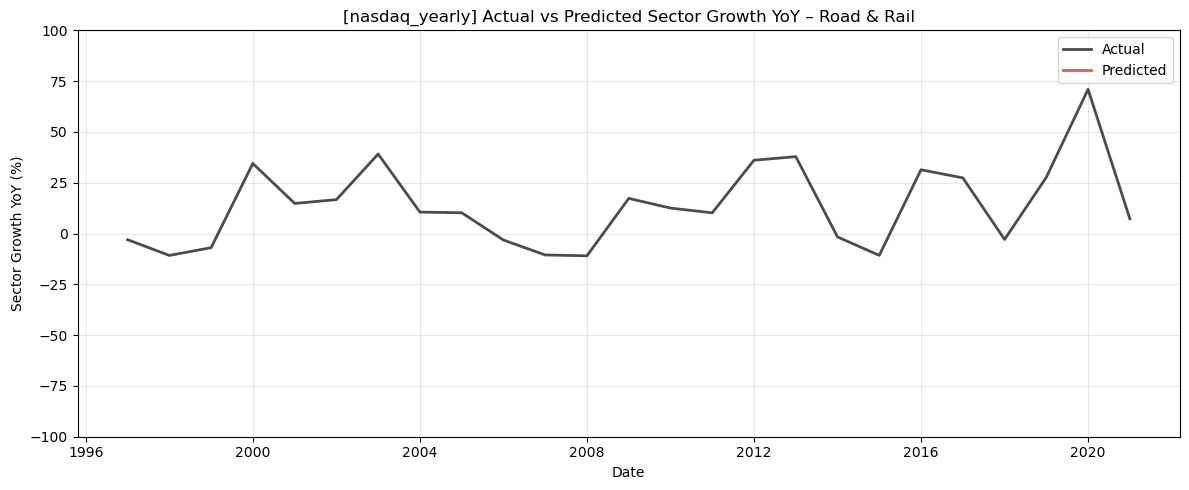

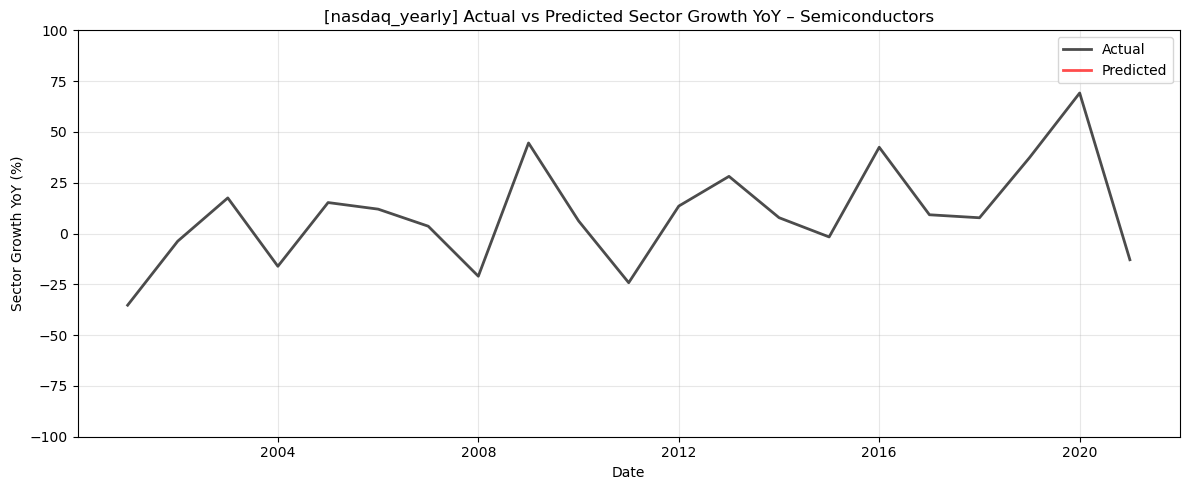

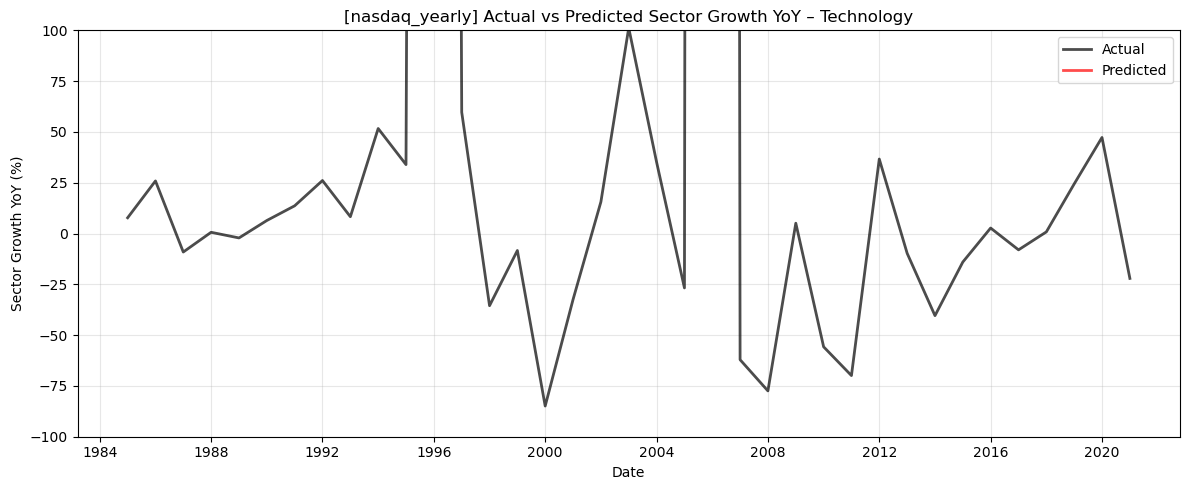

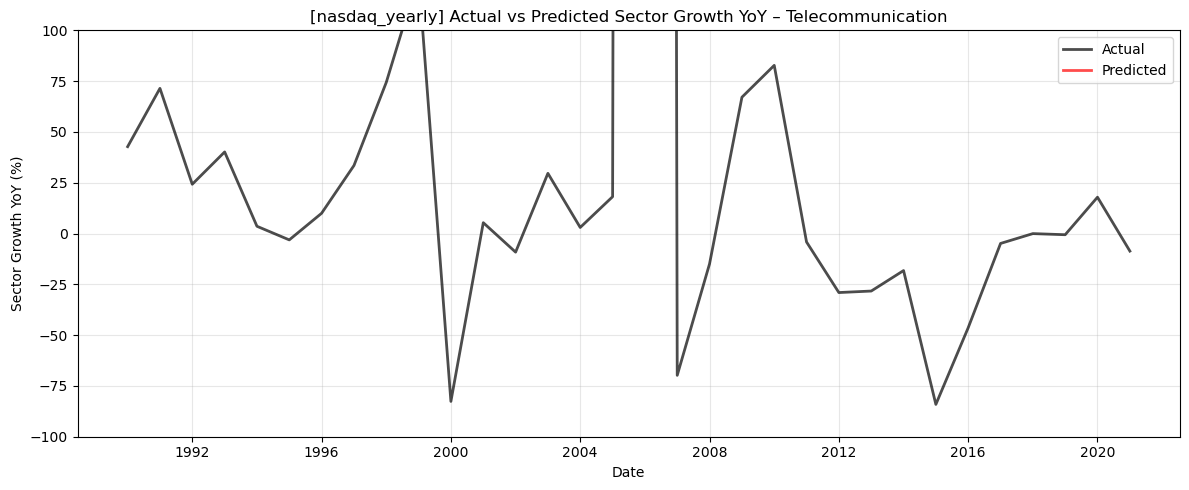

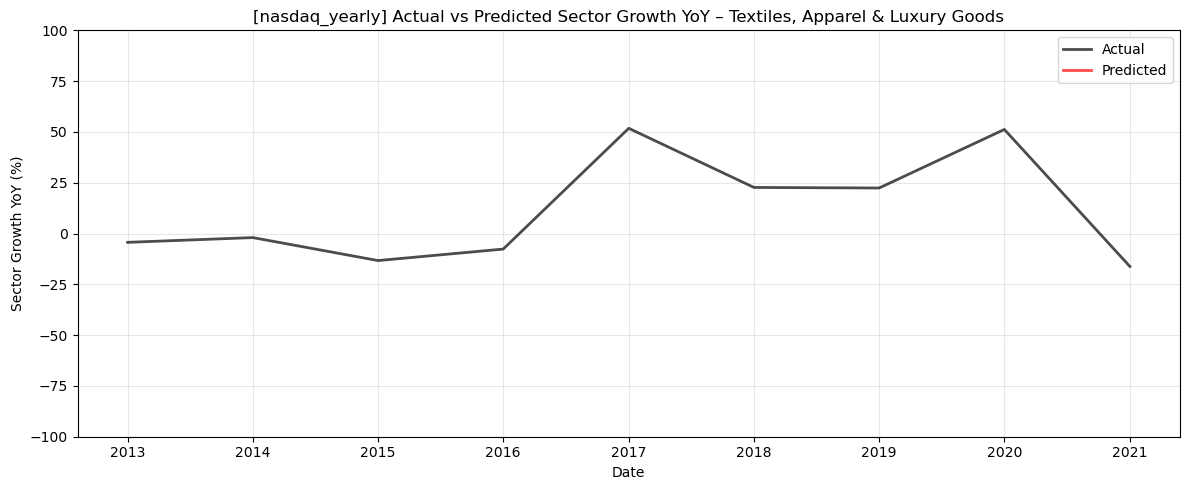

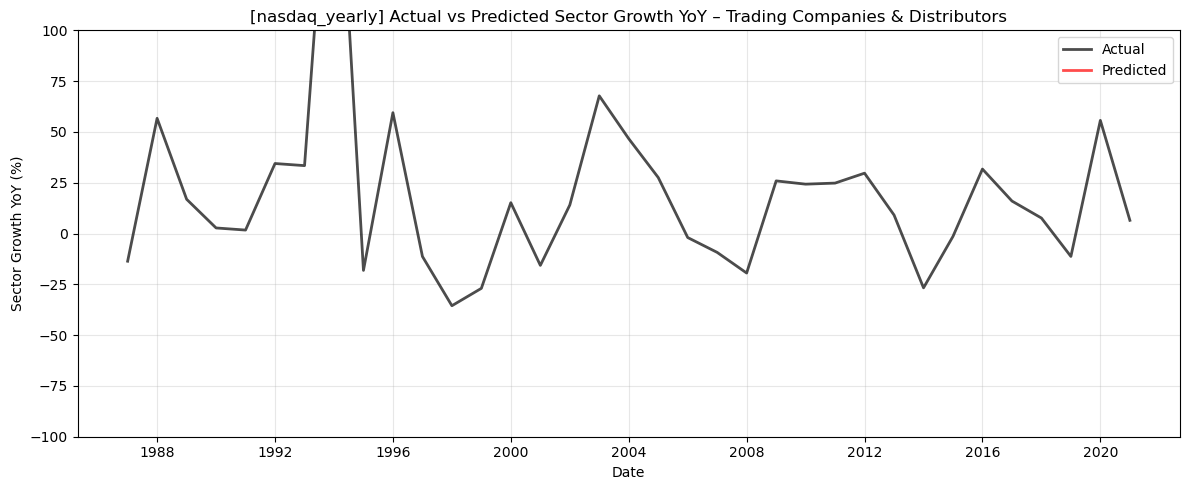

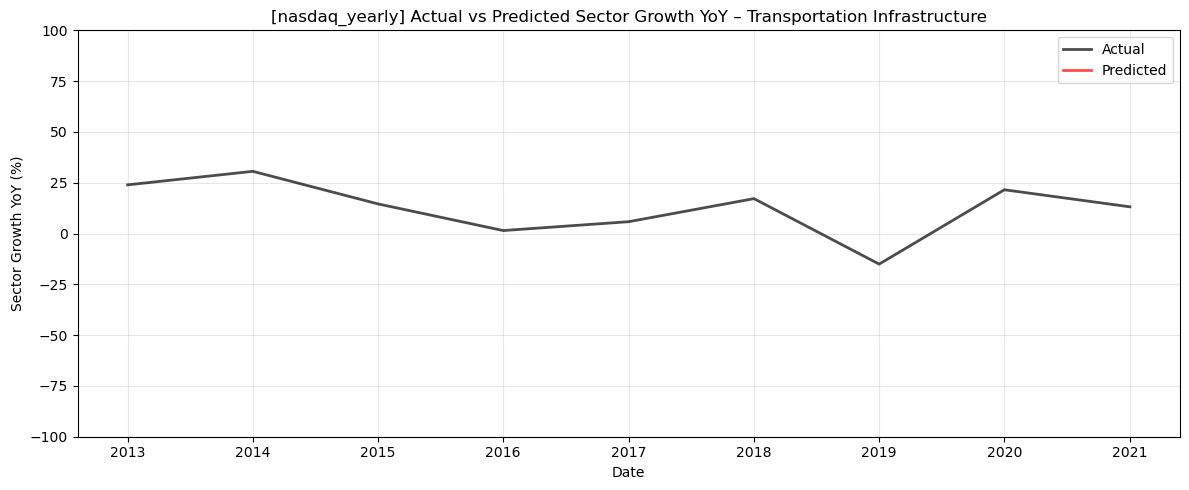

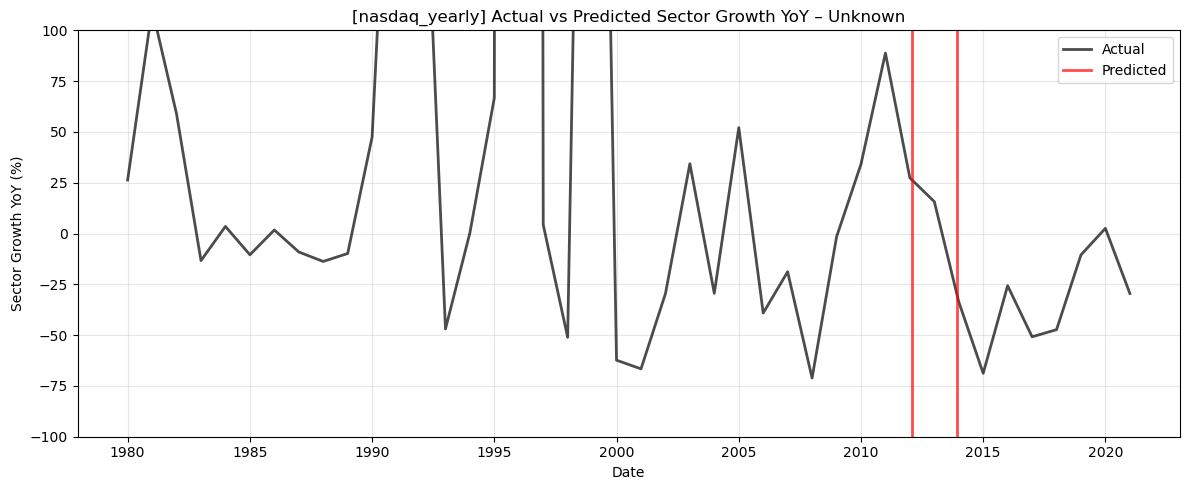

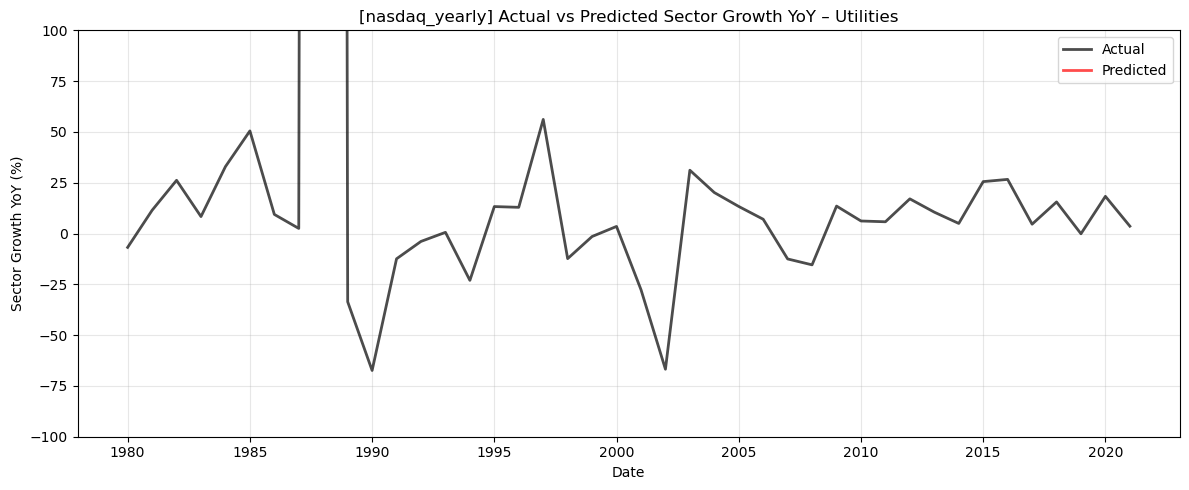


PER-SECTOR METRICS (nasdaq_yearly)

----------------------------------------------------------------------
Sector: Road & Rail
MAE  : 39152973810.2597
RMSE : 39280121234.2884
R²   : -3806538218330569728.0000
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
1997-01-01     -3.044738402519040.0000-38402519043.0447
1998-01-01    -10.774339571636224.0000-39571636234.7743
1999-01-01     -6.965735472510976.0000-35472510982.9657
2000-01-01     34.464434130397184.0000-34130397149.5356
2001-01-01     14.806336010795008.0000-36010794993.1937

----------------------------------------------------------------------
Sector: Semiconductors
MAE  : 33734591429.7332
RMSE : 33841572496.6327
R²   : -1893246316397403904.0000
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 1, 5)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_layer (LSTM)                   │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_layer (Dense)                  │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Activation)                  │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0011 - val_loss: 4.7405e-05
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.3946e-05
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.6078e-05
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 3.6176e-05
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 3.6249e-05
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.6434e-05
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 3.6593e-05
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.6760e-05
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.6933e-05
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.7113e-05
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 3.7300e-05
Epoch 12/30
29/29 ━━━━━━━━━━━

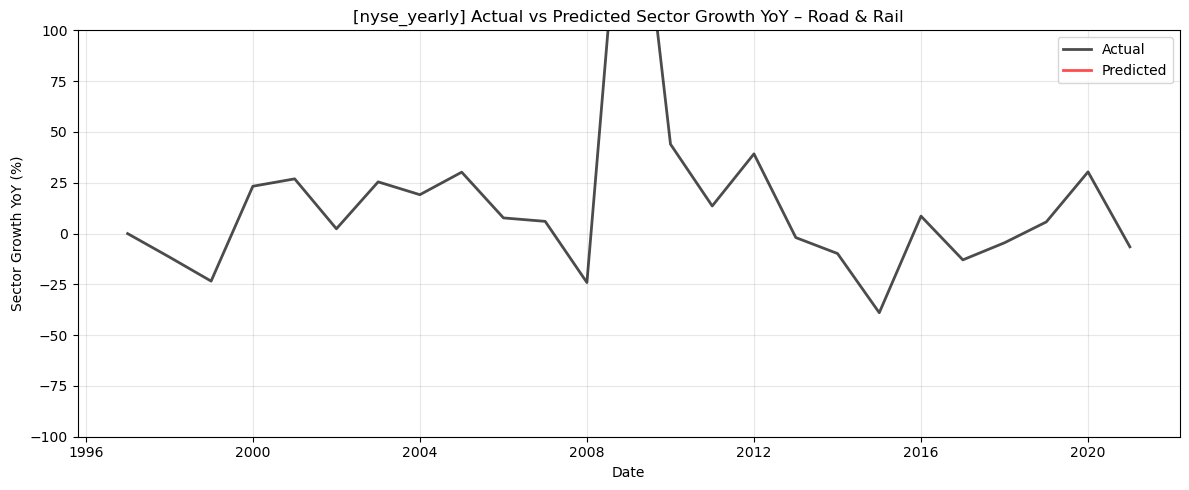

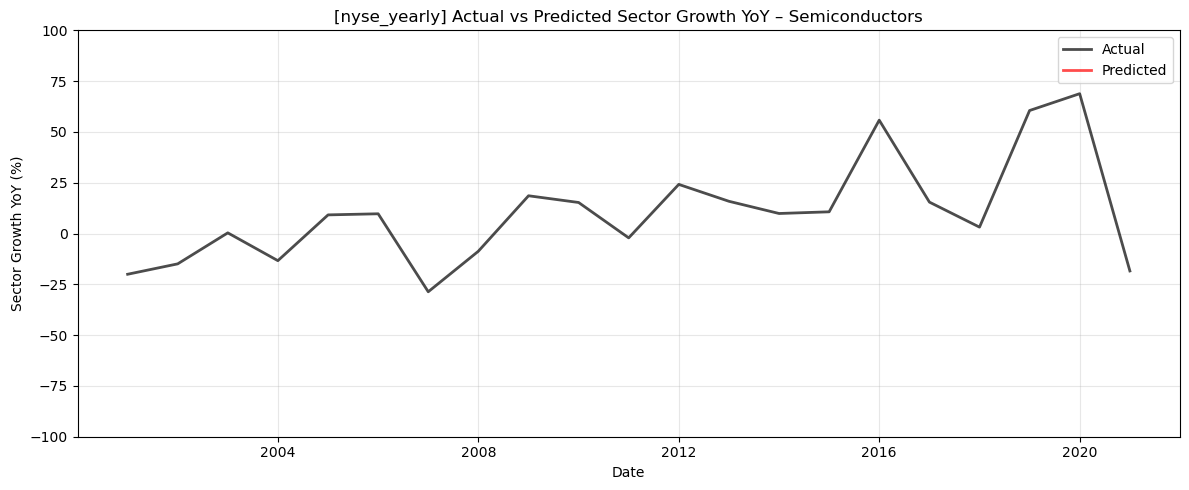

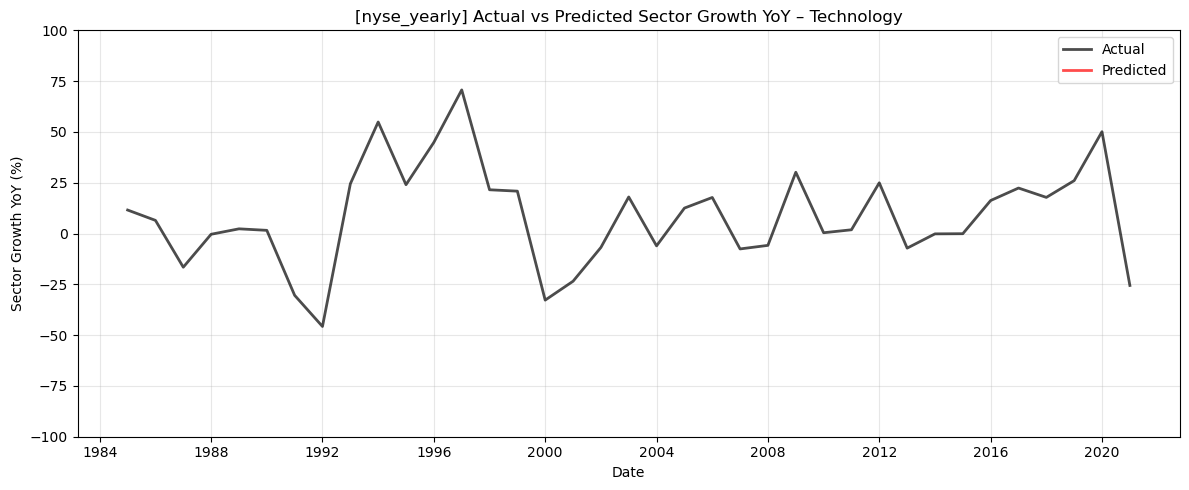

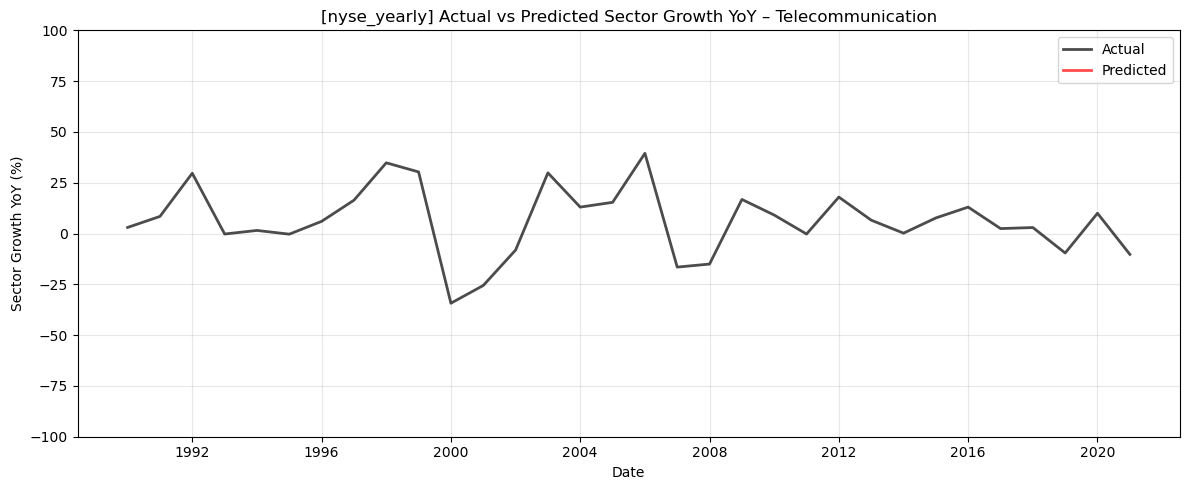

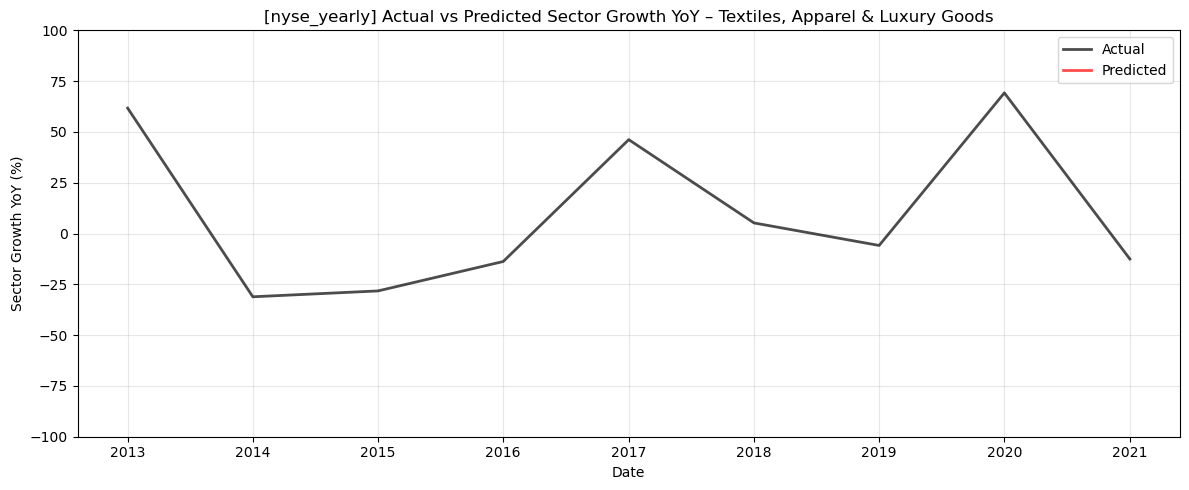

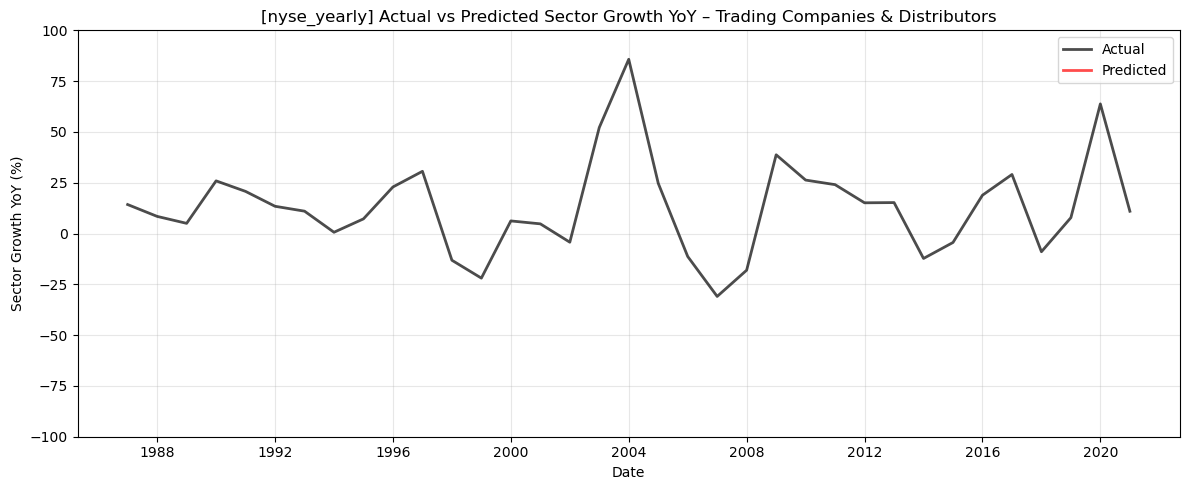

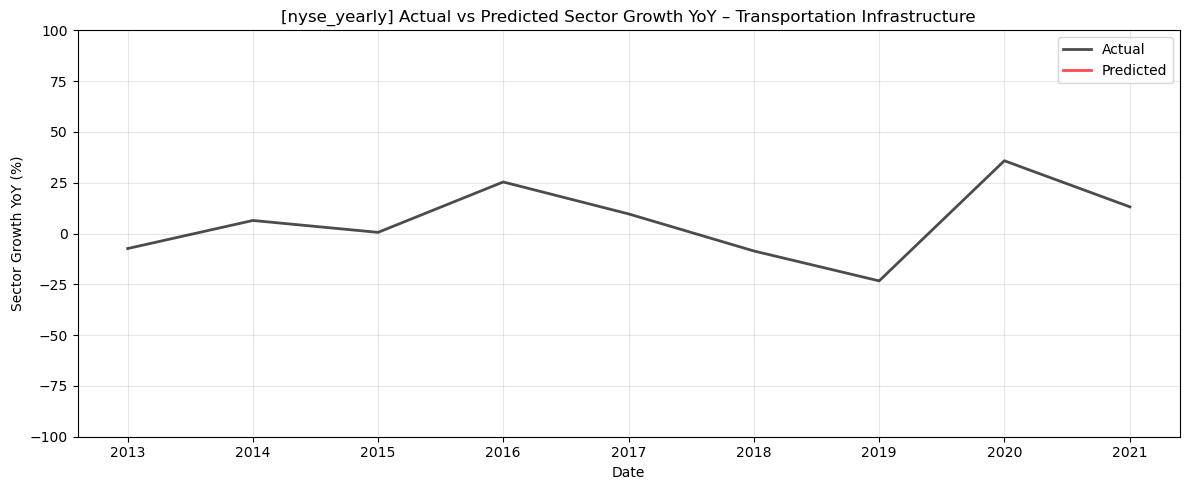

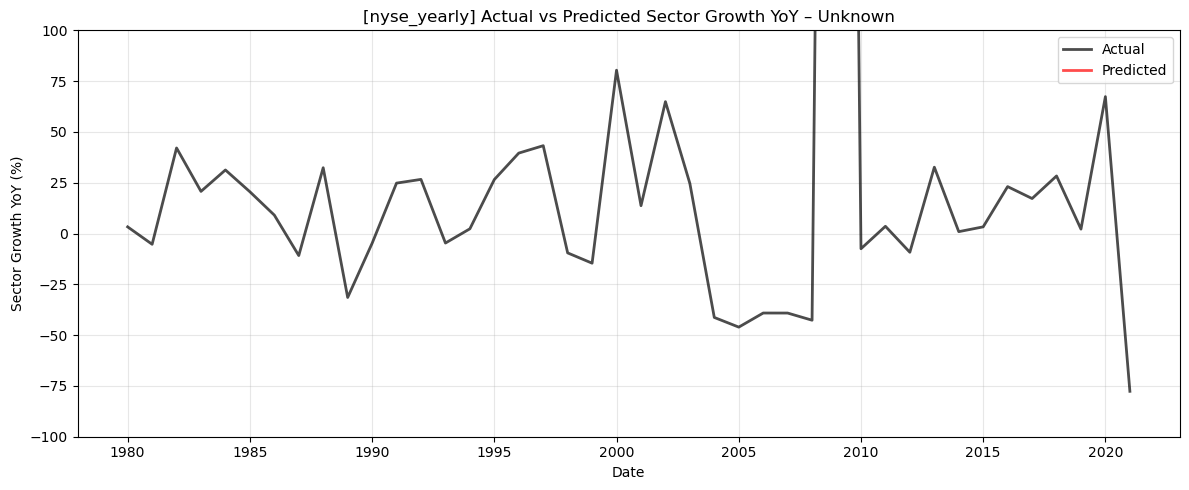

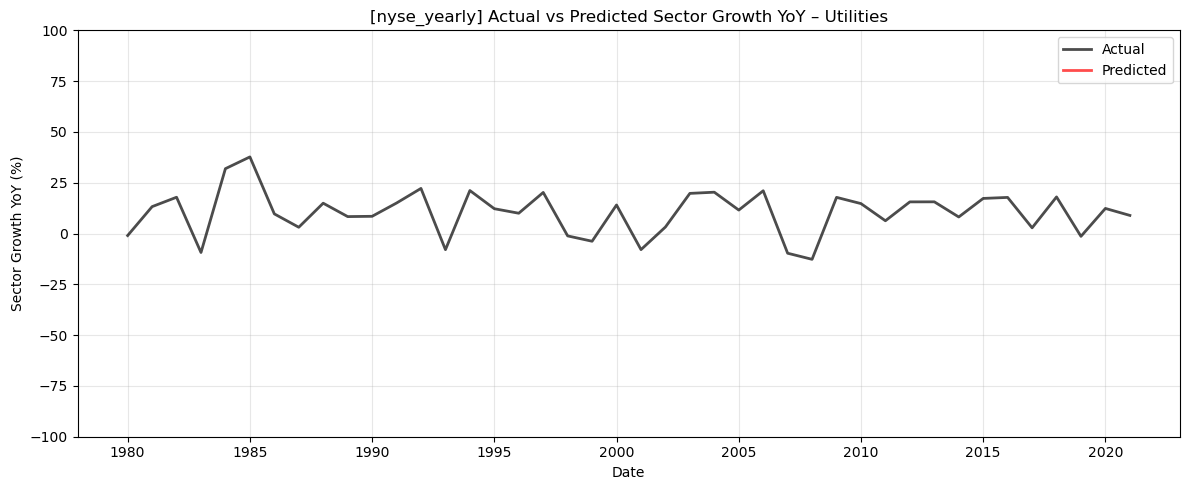


PER-SECTOR METRICS (nyse_yearly)

----------------------------------------------------------------------
Sector: Road & Rail
MAE  : 160122.7174
RMSE : 160449.7543
R²   : -11695320.4203
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
1997-01-01     -0.0386 164753.4062-164753.4449
1998-01-01    -11.5685 160077.7812-160089.3498
1999-01-01    -23.4200 154206.9531-154230.3732
2000-01-01     23.2623 153055.3594-153032.0970
2001-01-01     26.9052 147841.8906-147814.9854

----------------------------------------------------------------------
Sector: Semiconductors
MAE  : 141653.2837
RMSE : 141888.9837
R²   : -31342047.5752
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
2001-01-01    -20.0445 156355.5625-15637

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)              │ (None, 1, 5)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_layer (LSTM)                   │ (None, 64)                  │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_layer (Dense)                  │ (None, 1)                   │              65 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Activation)                  │ (None, 1)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0080 - val_loss: 0.0013
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_l

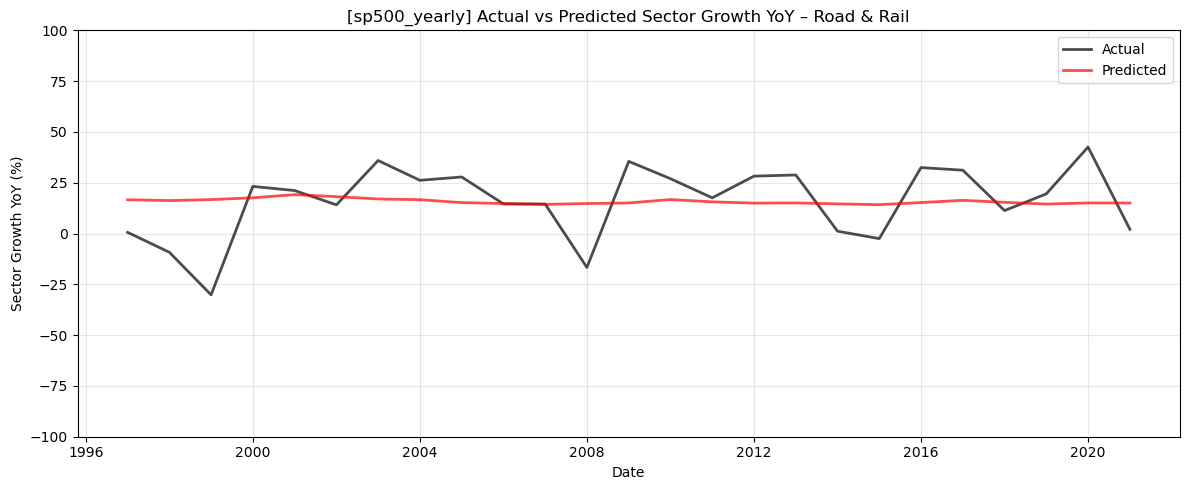

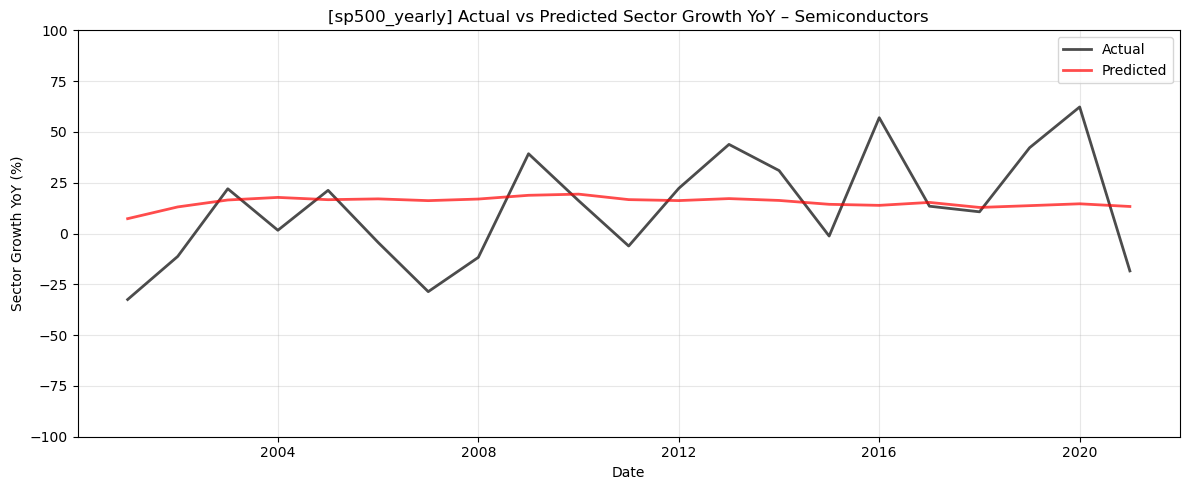

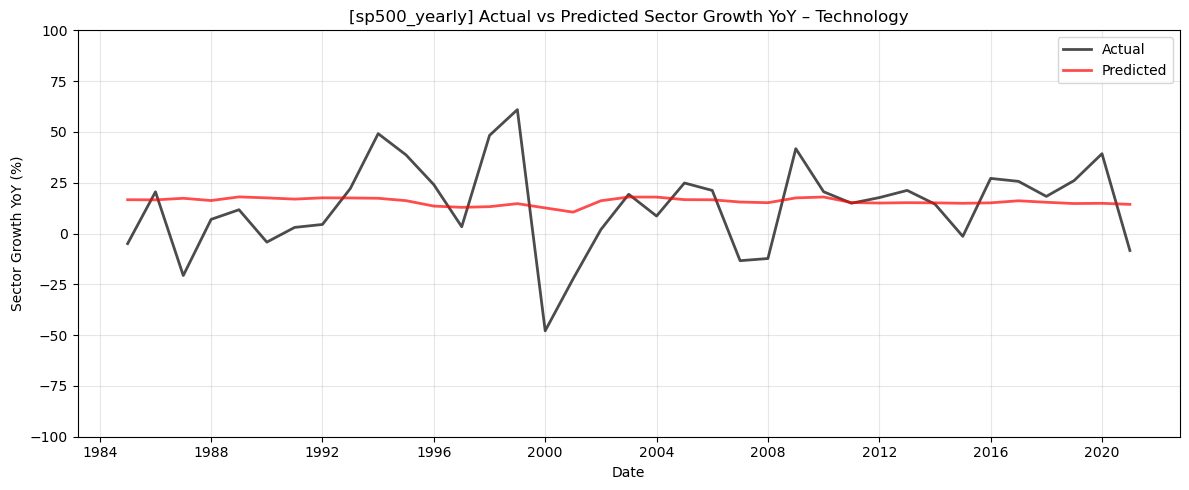

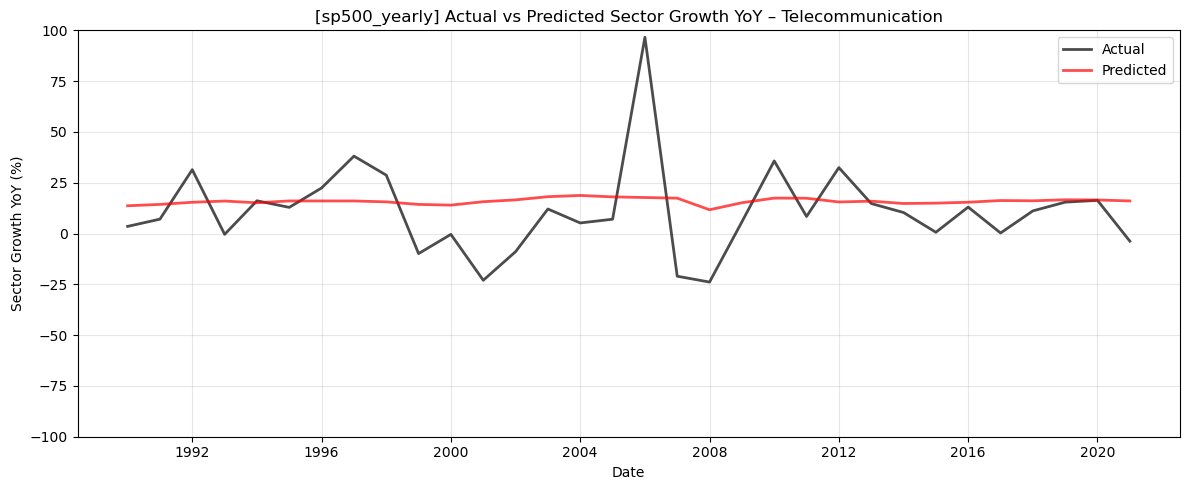

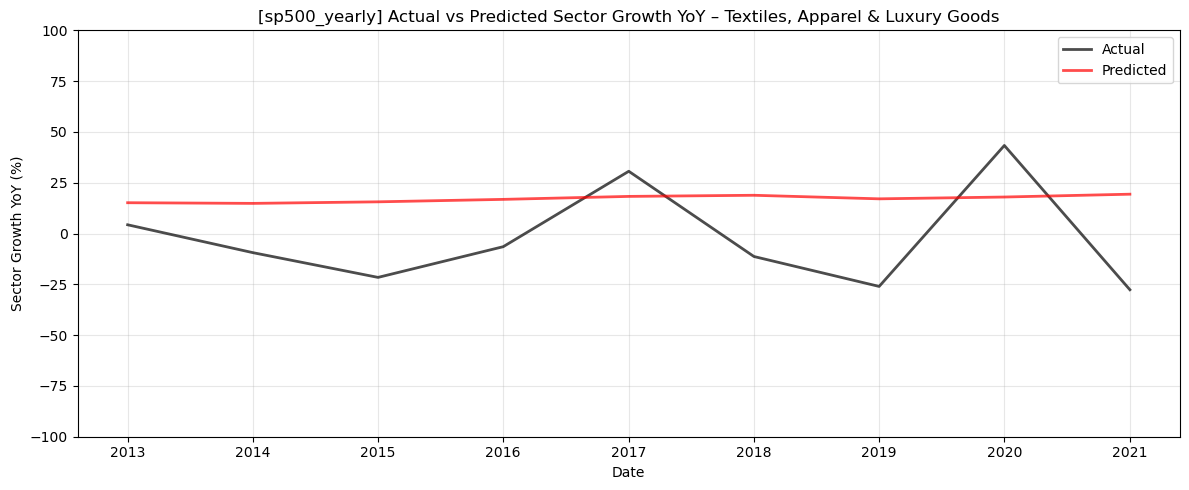

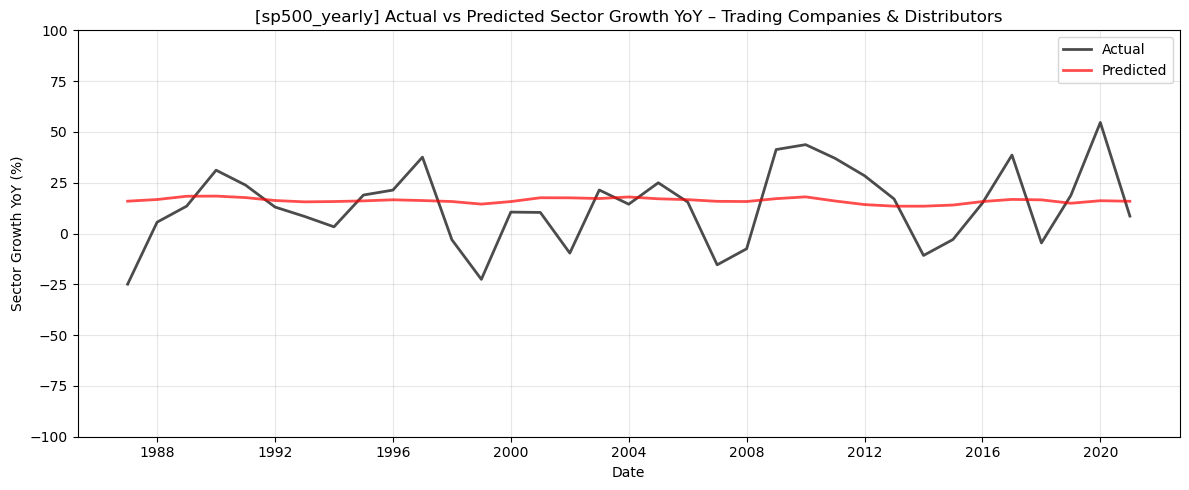

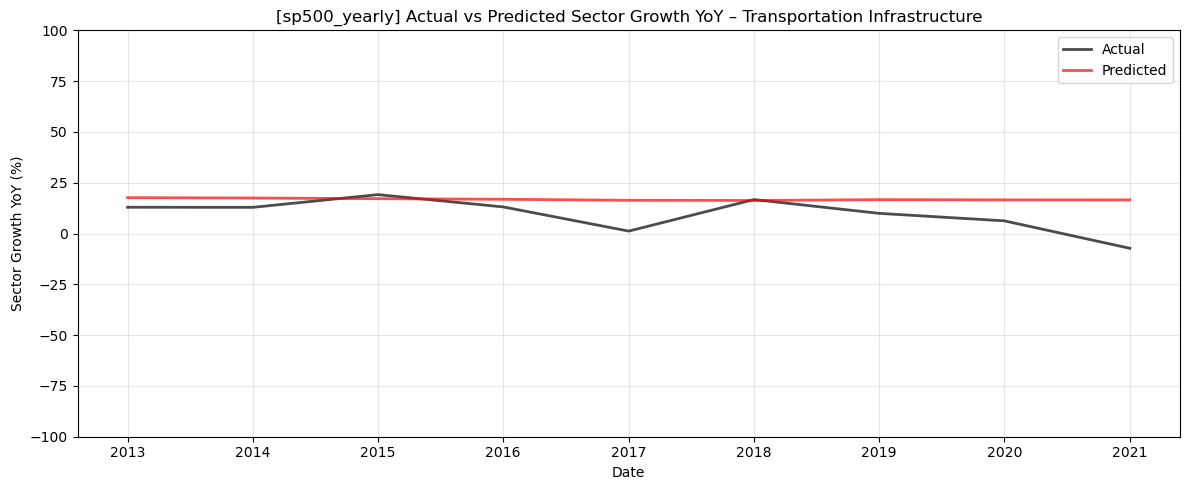

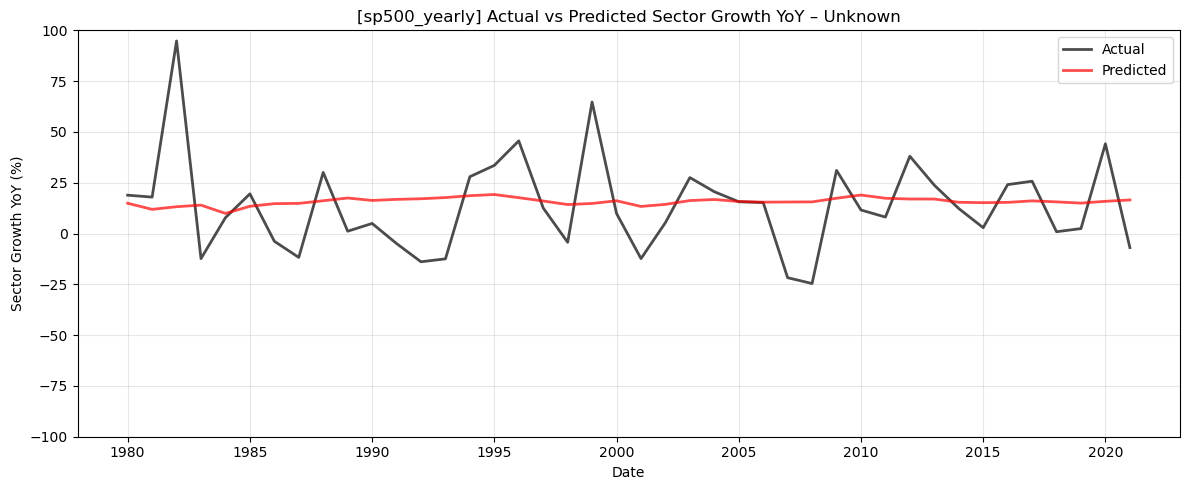

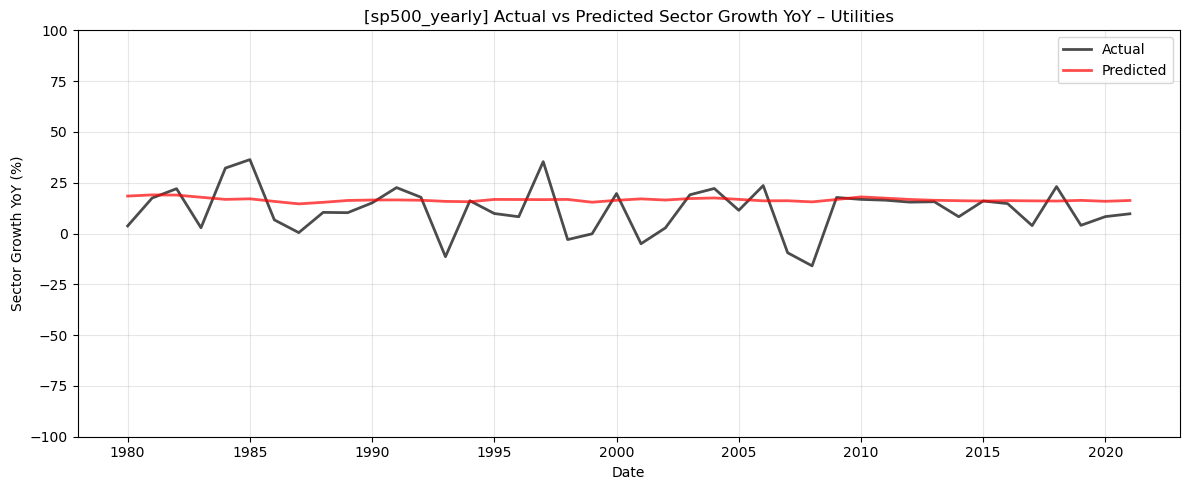


PER-SECTOR METRICS (sp500_yearly)

----------------------------------------------------------------------
Sector: Road & Rail
MAE  : 13.7765
RMSE : 17.4243
R²   : 0.0039
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
1997-01-01      0.5636     16.6388    -16.0752
1998-01-01     -9.2239     16.2084    -25.4324
1999-01-01    -30.1886     16.7076    -46.8962
2000-01-01     23.1938     17.5870      5.6068
2001-01-01     21.1531     19.1382      2.0149

----------------------------------------------------------------------
Sector: Semiconductors
MAE  : 21.4255
RMSE : 25.7236
R²   : 0.0365
----------------------------------------------------------------------
Date             Actual    Predicted        Error
----------------------------------------------------------------------
2001-01-01    -32.4781      7.3119    -39.7900
2002-01-01    -11.2620  

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandas_ta as ta

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Activation
from tensorflow.keras.optimizers import Adam

# ============================================================
# 0. GLOBAL CONFIG
# ============================================================

BASE_DIR = r'C:/Users/Abel/Downloads/PAN4/Semester 1/Data Analytics and Data Mining (CSC1171)/group_project/new_datasets'
BACKCANDLES = 1       # history length (you chose 1 – one-step Markov-ish)

np.random.seed(10)
tf.random.set_seed(10)

pd.set_option('display.max_columns', None)

# ------------------------------------------------------------
# simple manual MinMax
# ------------------------------------------------------------
def minmax_fit(arr):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        raise ValueError("minmax_fit received empty array.")
    min_vals = arr.min(axis=0)
    max_vals = arr.max(axis=0)
    denom = max_vals - min_vals
    denom[denom == 0.0] = 1.0
    return min_vals, max_vals

def minmax_transform(arr, min_vals, max_vals):
    arr = np.asarray(arr, dtype=float)
    denom = max_vals - min_vals
    denom[denom == 0.0] = 1.0
    return (arr - min_vals) / denom

def build_sequences_multi_sector(df, feat_cols_sc, target_col, backcandles, date_col="Date"):
    X_list, y_list = [], []
    meta_sector, meta_date = [], []

    for sector_name, grp in df.groupby('sector'):
        grp = grp.sort_values(date_col)
        feat_vals = grp[feat_cols_sc].values   # (T, n_features)
        tgt_vals  = grp[target_col].values     # (T,)
        dates     = grp[date_col].values

        if len(grp) <= backcandles:
            continue

        for i in range(backcandles, len(grp)):
            X_list.append(feat_vals[i-backcandles:i, :])
            y_list.append(tgt_vals[i])
            meta_sector.append(sector_name)
            meta_date.append(dates[i])

    X_arr = np.array(X_list)                  # (samples, backcandles, n_features)
    y_arr = np.array(y_list).reshape(-1, 1)   # (samples, 1)
    return X_arr, y_arr, np.array(meta_sector), np.array(meta_date)

# ---------- metric helpers ----------
def mse(a, b):
    return np.mean((a - b) ** 2)

def mae(a, b):
    return np.mean(np.abs(a - b))

def r2(a, b):
    ss_res = np.sum((a - b) ** 2)
    ss_tot = np.sum((a - np.mean(a)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0

# ============================================================
# MAIN PIPELINE FOR ONE DATASET
# ============================================================

def run_lstm_for_dataset(csv_path, dataset_name):
    print("\n" + "="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)

    # 1. LOAD DATA
    if not os.path.exists(csv_path):
        print(f"CSV not found: {csv_path}  → skipping")
        return

    data = pd.read_csv(csv_path)
    print(f"Raw data shape: {data.shape}")

    # Decide yearly vs monthly
    is_yearly = dataset_name.endswith("yearly")

    # Normalise time column to 'Date'
    if 'YearMonth' in data.columns:
        data['Date'] = pd.to_datetime(data['YearMonth'])
    elif 'Year' in data.columns:
        data['Date'] = pd.to_datetime(data['Year'].astype(int).astype(str) + '-01-01')
    else:
        print("No 'YearMonth' or 'Year' column found → skipping dataset")
        return

    data = data.sort_values(['sector', 'Date']).reset_index(drop=True)

    # 2. ADD INDICATORS ON sector_growth_yoy (PER SECTOR)
    #    Use shorter windows for yearly data.
    if is_yearly:
        rsi_len  = 5
        emaf_len = 5
        emam_len = 7   
        emas_len = 10
    else:
        rsi_len  = 15
        emaf_len = 20
        emam_len = 100
        emas_len = 150

    data['RSI'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.rsi(s, length=rsi_len))
    )

    data['EMAF'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=emaf_len))
    )

    data['EMAM'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=emam_len))
    )

    data['EMAS'] = (
        data.groupby('sector')['sector_growth_yoy']
            .transform(lambda s: ta.ema(s, length=emas_len))
    )

    # 3. TARGET = NEXT-PERIOD sector_growth_yoy PER SECTOR
    data['Target'] = (
        data.groupby('sector')['sector_growth_yoy']
            .shift(-1)
    )

    # 4. FEATURES: yearly uses fewer TA features, monthly keeps EMAM
    if is_yearly:
        feature_cols = [
            'avg_return',
            'avg_adj_close',
            'avg_volume',
            'RSI',
            'EMAF',
        ]
    else:
        feature_cols = [
            'avg_return',
            'avg_adj_close',
            'avg_volume',
            'RSI',
            'EMAF',
            'EMAM',
        ]

    target_col = 'Target'

    # Sanity-check feature columns
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        print(f"Missing feature columns {missing} in {dataset_name} → skipping")
        return

    # Drop only rows with NaNs in features/target
    cols_needed = feature_cols + [target_col]
    data = data.dropna(subset=cols_needed).reset_index(drop=True)
    print(f"After dropna on features+Target, shape: {data.shape}")

    if len(data) == 0:
        print("No rows left after dropna (features/Target) → skipping this dataset")
        return

    # 5. SCALE FEATURES
    feat = data[feature_cols].values
    tgt  = data[target_col].values.reshape(-1, 1)

    if feat.shape[0] == 0:
        print("No feature rows after selection → skipping dataset")
        return

    feat_min, feat_max = minmax_fit(feat)
    feat_scaled = minmax_transform(feat, feat_min, feat_max)

    scaled_feat_cols = [c + '_sc' for c in feature_cols]
    data[scaled_feat_cols] = feat_scaled

    # 6. BUILD SEQUENCES
    X, y, sectors_arr, dates_arr = build_sequences_multi_sector(
        data,
        scaled_feat_cols,
        target_col,
        BACKCANDLES,
        date_col="Date",
    )

    if len(X) == 0:
        print("Not enough data to build sequences → skipping dataset")
        return

    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")

    # 7. TRAIN–TEST SPLIT
    split_idx = int(len(X) * 0.8)

    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    sectors_test = sectors_arr[split_idx:]
    dates_test   = dates_arr[split_idx:]

    print(f"Train samples: {X_train.shape[0]}  |  Test samples: {X_test.shape[0]}")

    n_features = X.shape[2]

    # SCALE TARGET (MinMax on training part only)
    y_min = y_train.min()
    y_max = y_train.max()
    y_range = y_max - y_min if (y_max - y_min) != 0 else 1.0

    y_train_sc = (y_train - y_min) / y_range
    y_test_sc  = (y_test  - y_min) / y_range

    # 8. BUILD AND TRAIN LSTM
    lstm_input = Input(shape=(BACKCANDLES, n_features), name='lstm_input')
    x = LSTM(64, name='first_layer')(lstm_input)
    x = Dense(1, name='dense_layer')(x)
    output = Activation('linear', name='output')(x)

    model = Model(inputs=lstm_input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')

    print("\nModel summary:")
    model.summary()

    history = model.fit(
        X_train, y_train_sc,
        batch_size=32,
        epochs=30,
        shuffle=True,
        validation_split=0.1,
        verbose=1
    )

    # 9. PREDICT (IN REAL UNITS)
    y_pred_sc = model.predict(X_test)
    y_pred = y_pred_sc * y_range + y_min

    # 10. PLOT TEST vs PREDICTED – PER SECTOR
    unique_sectors = np.unique(sectors_test)

    for sector in unique_sectors:
        mask = (sectors_test == sector)

        sector_dates = dates_test[mask]
        sector_y_true = y_test[mask][:, 0]
        sector_y_pred = y_pred[mask][:, 0]

        sort_idx = np.argsort(sector_dates)
        sector_dates = sector_dates[sort_idx]
        sector_y_true = sector_y_true[sort_idx]
        sector_y_pred = sector_y_pred[sort_idx]

        plt.figure(figsize=(12, 5))
        plt.plot(
            sector_dates, sector_y_true,
            label='Actual', color='black', linewidth=2, alpha=0.7
        )
        plt.plot(
            sector_dates, sector_y_pred,
            label='Predicted', color='red', linewidth=2, alpha=0.7
        )
        plt.xlabel('Date')
        plt.ylabel('Sector Growth YoY (%)')
        plt.ylim(-100, 100)
        plt.title(f'[{dataset_name}] Actual vs Predicted Sector Growth YoY – {sector}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # 11. PER-SECTOR METRICS
    sector_summary = []

    print("\n" + "="*70)
    print(f"PER-SECTOR METRICS ({dataset_name})")
    print("="*70)

    for sector in unique_sectors:
        mask = (sectors_test == sector)

        sector_dates = dates_test[mask]
        sector_y_true = y_test[mask][:, 0]
        sector_y_pred = y_pred[mask][:, 0]

        sort_idx = np.argsort(sector_dates)
        sector_dates = sector_dates[sort_idx]
        sector_y_true = sector_y_true[sort_idx]
        sector_y_pred = sector_y_pred[sort_idx]

        sector_mae = mae(sector_y_true, sector_y_pred)
        sector_rmse = np.sqrt(mse(sector_y_true, sector_y_pred))
        sector_r2 = r2(sector_y_true, sector_y_pred)

        sector_summary.append({
            "Sector": sector,
            "MAE": sector_mae,
            "RMSE": sector_rmse,
            "R2": sector_r2,
        })

        print("\n" + "-"*70)
        print(f"Sector: {sector}")
        print(f"MAE  : {sector_mae:.4f}")
        print(f"RMSE : {sector_rmse:.4f}")
        print(f"R²   : {sector_r2:.4f}")
        print("-"*70)
        print(f"{'Date':<12} {'Actual':>10} {'Predicted':>12} {'Error':>12}")
        print("-"*70)

        for i in range(min(5, len(sector_y_true))):
            err = sector_y_true[i] - sector_y_pred[i]
            print(
                f"{str(sector_dates[i])[:10]:<12}"
                f"{sector_y_true[i]:10.4f}"
                f"{sector_y_pred[i]:12.4f}"
                f"{err:12.4f}"
            )

    # compact summary
    print("\n" + "="*70)
    print(f"SUMMARY TABLE ({dataset_name})")
    print("="*70)
    for row in sector_summary:
        print(
            f"{row['Sector']:<30} "
            f"MAE={row['MAE']:.4f}  "
            f"RMSE={row['RMSE']:.4f}  "
            f"R²={row['R2']:.4f}"
        )

# ============================================================
# RUN FOR ALL DATASETS
# ============================================================

DATASETS = [
    "forbes2000_yearly",
    "nasdaq_yearly",
    "nyse_yearly",
    "sp500_yearly",
]

for ds in DATASETS:
    csv_path = os.path.join(BASE_DIR, f"{ds}.csv")
    run_lstm_for_dataset(csv_path, ds)